# Demo 1 — Customer complaint classification
## From raw complaint data to a triage model

*AI Architecture — Day 1, live demo 1*

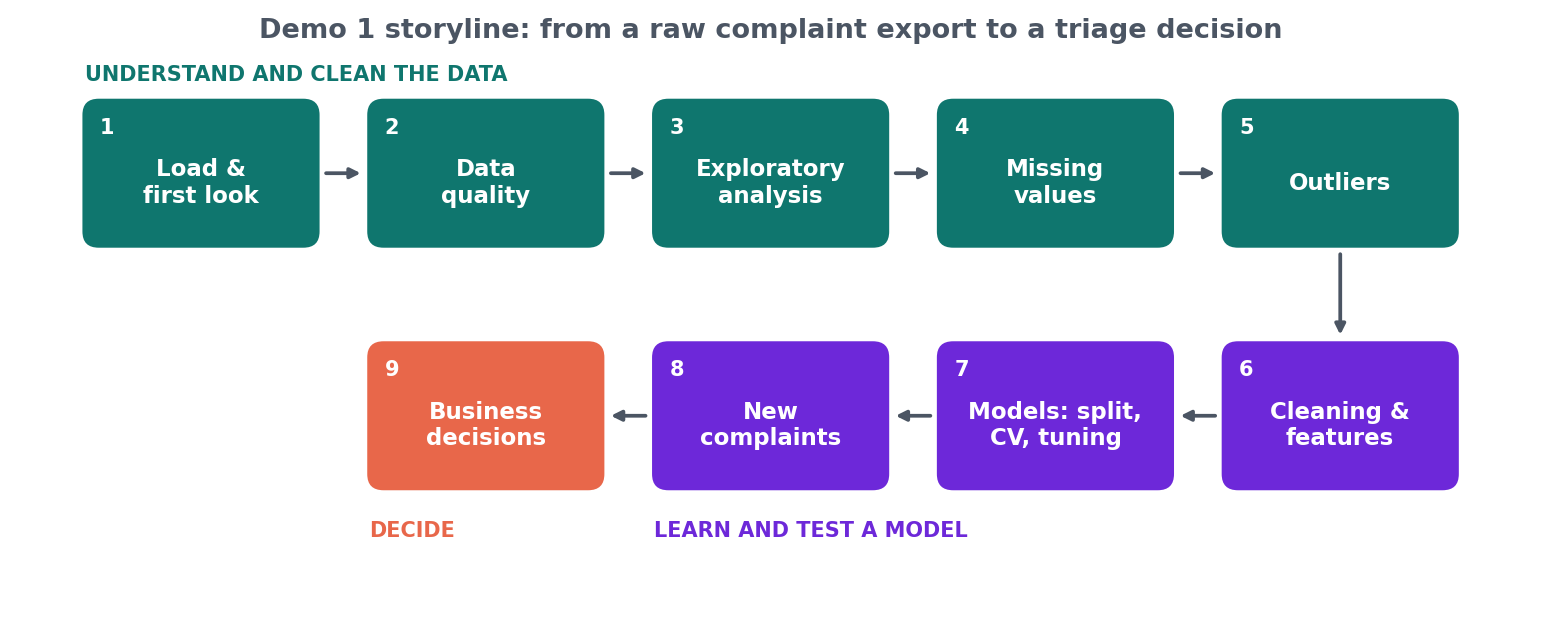

### The business situation

A bank receives thousands of customer complaints every year. Each complaint is logged in the
complaint-management system with structured attributes (product, channel, customer segment, disputed
amount, previous contacts, ...) and, when the complaint arrives in writing, with two features derived from the
text: its length and a **sentiment score** produced by an upstream NLP/LLM step (how negative the tone is,
from −1 to +1). Building that step with an LLM is the subject of the prompt-engineering module; here we take
its output as given.

The handling of a complaint ends in one of three ways:

| Outcome | What it means for the bank |
|---|---|
| **Resolved at first contact** | closed by the front line, low cost |
| **Resolved after investigation** | back-office work, days or weeks of handling |
| **Escalated to ombudsman** | the customer goes to the external dispute body: fees, compensation, reputational damage, regulatory attention |

### The business question

*Can we predict, the moment a complaint is filed, how it will end?*

If we can, we can **triage**: route likely escalations to senior handlers immediately, offer a goodwill
gesture early, and keep the simple cases in the fast lane.

**Opportunities**

- **Cost.** Escalations are the expensive tail: handling time, ombudsman fees, compensation.
- **Deadlines.** Regulators impose reply deadlines (for example 15 business days for payment-service
  complaints under PSD2). A late answer is itself a reason to escalate.
- **Retention.** A complaint handled well is a loyalty moment; handled badly, it often precedes churn.
- **Early warning.** Complaint volumes are a sensor for operational incidents and product problems.

**Risks**

- **Data quality.** The model learns from what was logged, errors included. This is why most of the demo is
  about looking at the data before modelling it.
- **Leakage.** Using information that is not available at intake makes a model look brilliant in the lab and
  useless in production.
- **Fairness and compliance.** Triage must not systematically de-prioritise a group of customers
  (GDPR rules on profiling; EU AI Act principles of oversight and transparency).
- **Automation bias.** A prediction is a suggestion for the handler, not a decision.

### How the demo unfolds

1. Load the data and take a first look
2. Data-quality checks (duplicates, inconsistent labels)
3. Exploratory data analysis (EDA)
4. Missing values: mechanisms and strategies
5. Outliers: from the box plot to the Mahalanobis distance
6. Cleaning decisions and feature preparation (including the leakage trap)
7. Three classification models: train/test split, cross-validation, hyper-parameter tuning
8. Predictions on new complaints
9. Business wrap-up

*A note for the technical audience.* The code is deliberately plain: `pandas`, `matplotlib`, `plotly`
and `scikit-learn`, no custom functions or pipelines beyond the strict minimum. In a production project
much of this would be packaged and automated; here readability wins.

### Data dictionary

| Column | Meaning | Known at intake? |
|---|---|---|
| `complaint_id` | unique identifier | yes |
| `complaint_date` | date the complaint was registered | yes |
| `product` | product the complaint refers to | yes |
| `channel` | channel used to complain | yes |
| `customer_segment` | Retail, Affluent, SME, Private | yes |
| `customer_age` | age in years | yes |
| `tenure_years` | years as a customer | yes |
| `products_held` | number of products held | yes |
| `disputed_amount` | amount claimed, EUR | yes |
| `prior_complaints_12m` | complaints filed in the previous 12 months | yes |
| `contacts_before_complaint` | contacts about the issue before the formal complaint | yes |
| `days_since_event` | days between the disputed event and the complaint | yes |
| `text_length_words` | length of the written complaint | yes (if written) |
| `sentiment_score` | tone of the text, −1 (very negative) to +1 | yes (if written) |
| `compensation_eur` | compensation paid at closure | **no — post-closure** |
| `outcome` | **target**: how the complaint ended | **no — this is what we predict** |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px                  # if missing: pip install plotly nbformat
from scipy.stats import chi2

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4)

# a small palette reused in the plots: teal, purple, coral, grey
TEAL, PURPLE, CORAL, GREY = "#0F766E", "#6D28D9", "#E8674A", "#4B5563"
OUTCOME_ORDER = ["Resolved at first contact", "Resolved after investigation", "Escalated to ombudsman"]
OUTCOME_COLORS = {"Resolved at first contact": TEAL, "Resolved after investigation": PURPLE, "Escalated to ombudsman": CORAL}

## 1. Load the data and take a first look

The file is a plain CSV export of the complaint-management system. We ask `pandas` to parse the date column
while reading, so that it becomes a real date and not a string.

In [2]:
df = pd.read_csv("bank_complaints.csv", parse_dates=["complaint_date"])
print("Rows:", df.shape[0], "  Columns:", df.shape[1])
df.head()

Rows: 3006   Columns: 16


,complaint_id,complaint_date,product,channel,customer_segment,customer_age,tenure_years,products_held,disputed_amount,prior_complaints_12m,contacts_before_complaint,days_since_event,text_length_words,sentiment_score,outcome,compensation_eur
0,CMP-000001,2025-01-01,Credit card,Phone,Retail,57.0,10.2,4.0,93.51,0.0,1.0,18.0,NaN,NaN,Resolved at first contact,0.00
1,CMP-000002,2025-01-01,Mortgage,Mobile app,SME,30.0,1.1,2.0,NaN,1.0,2.0,36.0,174.0,-0.52,Resolved after investigation,783.79
2,CMP-000003,2025-01-01,Investments,Email,Affluent,49.0,8.8,5.0,1421.76,1.0,4.0,26.0,176.0,-0.69,Resolved after investigation,406.57
3,CMP-000004,2025-01-01,Mortgage,Phone,unknown,37.0,1.3,1.0,733.81,2.0,2.0,38.0,NaN,NaN,Resolved after investigation,300.69
4,CMP-000005,2025-01-01,Mortgage,Web form,Retail,47.0,6.0,2.0,749.28,0.0,2.0,38.0,205.0,-0.35,Resolved after investigation,0.00


**Data types.** A quick check of `dtypes` already tells a story: `customer_age` is a float although ages are
whole numbers. `pandas` stores a column as float as soon as it contains a missing value (`NaN`), so a float
column of counts is often the first sign of missing data.

In [3]:
df.dtypes

complaint_id                            str
complaint_date               datetime64[us]
product                                 str
channel                                 str
customer_segment                        str
customer_age                        float64
tenure_years                        float64
products_held                       float64
disputed_amount                     float64
prior_complaints_12m                float64
contacts_before_complaint           float64
days_since_event                    float64
text_length_words                   float64
sentiment_score                     float64
outcome                                 str
compensation_eur                    float64
dtype: object

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3006 entries, 0 to 3005
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   complaint_id               3006 non-null   str           
 1   complaint_date             3006 non-null   datetime64[us]
 2   product                    3006 non-null   str           
 3   channel                    3006 non-null   str           
 4   customer_segment           3006 non-null   str           
 5   customer_age               2884 non-null   float64       
 6   tenure_years               3006 non-null   float64       
 7   products_held              3006 non-null   float64       
 8   disputed_amount            2756 non-null   float64       
 9   prior_complaints_12m       3006 non-null   float64       
 10  contacts_before_complaint  3006 non-null   float64       
 11  days_since_event           3006 non-null   float64       
 12  text_length_words

**Numeric summary.** `describe()` gives count, mean, standard deviation and quartiles. Three things to read here:

- the `count` differs across columns: some have missing values;
- the `mean` of `disputed_amount` is far above its median (`50%`): the distribution is skewed, with a long tail of
  large amounts;
- the `max` values of `customer_age`, `text_length_words` and `days_since_event` look suspicious.

In [5]:
df.describe().round(2).T

,count,mean,min,25%,50%,75%,max,std
complaint_date,3006,2025-10-11 21:48:44.550898,2025-01-01 00:00:00,2025-05-22 00:00:00,2025-11-03 00:00:00,2026-02-13 00:00:00,2026-06-30 00:00:00,NaN
customer_age,2884.0,46.92,18.0,38.0,46.0,56.0,134.0,13.61
tenure_years,3006.0,9.0,0.0,3.9,8.6,13.3,30.7,6.34
products_held,3006.0,4.0,1.0,2.0,4.0,5.0,8.0,1.95
disputed_amount,2756.0,958.07,7.66,168.54,417.28,957.41,62514.0,2441.83
prior_complaints_12m,3006.0,0.93,0.0,0.0,1.0,1.0,4.0,0.83
contacts_before_complaint,3006.0,2.4,0.0,1.0,2.0,3.0,7.0,1.42
days_since_event,3006.0,26.14,0.0,16.0,26.0,35.0,1450.0,29.59
text_length_words,2246.0,172.27,20.0,123.0,163.0,201.0,12400.0,333.47
sentiment_score,2245.0,-0.3,-1.0,-0.52,-0.3,-0.1,0.65,0.3


**Non-numeric columns.** For text and date columns `describe()` reports the number of distinct values and
the most frequent one. Note the number of distinct values of `channel`: we expect 6 channels.

In [6]:
df.select_dtypes(exclude="number").describe().T

,count,mean,min,25%,50%,75%,max
complaint_date,3006,2025-10-11 21:48:44.550898,2025-01-01 00:00:00,2025-05-22 00:00:00,2025-11-03 00:00:00,2026-02-13 00:00:00,2026-06-30 00:00:00


## 2. Data-quality checks

Before any analysis we look for the two most common defects of a system export: duplicated rows and
inconsistent category labels.

> **Business insight.** A `value_counts()` on every categorical column is the cheapest data-quality check
> there is, and it catches problems that no model can fix afterwards.

In [7]:
print("Exact duplicate rows:", df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values("complaint_id").head(6)

Exact duplicate rows: 6


,complaint_id,complaint_date,product,channel,customer_segment,customer_age,tenure_years,products_held,disputed_amount,prior_complaints_12m,contacts_before_complaint,days_since_event,text_length_words,sentiment_score,outcome,compensation_eur
104,CMP-000105,2025-01-19,Credit card,Email,SME,62.0,13.5,5.0,123.12,1.0,1.0,10.0,74.0,0.12,Resolved at first contact,0.0
105,CMP-000105,2025-01-19,Credit card,Email,SME,62.0,13.5,5.0,123.12,1.0,1.0,10.0,74.0,0.12,Resolved at first contact,0.0
204,CMP-000204,2025-02-10,Current account,Phone,Retail,32.0,2.6,3.0,NaN,1.0,3.0,36.0,NaN,NaN,Resolved at first contact,0.0
205,CMP-000204,2025-02-10,Current account,Phone,Retail,32.0,2.6,3.0,NaN,1.0,3.0,36.0,NaN,NaN,Resolved at first contact,0.0
224,CMP-000223,2025-02-12,Current account,Branch,SME,56.0,9.1,5.0,124.54,0.0,1.0,5.0,50.0,0.46,Resolved at first contact,0.0
225,CMP-000223,2025-02-12,Current account,Branch,SME,56.0,9.1,5.0,124.54,0.0,1.0,5.0,50.0,0.46,Resolved at first contact,0.0


In [8]:
df = df.drop_duplicates().reset_index(drop=True)
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 3000


In [9]:
for col in ["product", "channel", "customer_segment", "outcome"]:
    print(df[col].value_counts(dropna=False), "\n")

product
Current account    1048
Credit card         699
Mortgage            359
Investments         341
Personal loan       316
Insurance           237
Name: count, dtype: int64 

channel
Phone           899
Email           614
Mobile app      600
Web form        379
Branch          355
Social media    141
E-mail            5
email             4
Phone             3
Name: count, dtype: int64 

customer_segment
Retail      1952
Affluent     588
SME          264
Private      156
unknown       40
Name: count, dtype: int64 

outcome
Resolved at first contact       1430
Resolved after investigation    1146
Escalated to ombudsman           424
Name: count, dtype: int64 



Two problems appear:

- `channel` has spelling variants (`E-mail`, `email`, `Phone ` with a trailing space) that a model would treat as
  different channels;
- `customer_segment` contains the word `unknown`, which is a missing value written as text. `pandas` recognises
  empty cells as missing, but not the word "unknown".

We normalise the labels and turn `unknown` into a proper missing value, so that it is handled together with
the other missing values in section 4.

In [10]:
df["channel"] = df["channel"].str.strip().replace({"E-mail": "Email", "email": "Email"})
df["customer_segment"] = df["customer_segment"].replace("unknown", np.nan)

print(df["channel"].value_counts(), "\n")
print(df["customer_segment"].value_counts(dropna=False))

channel
Phone           902
Email           623
Mobile app      600
Web form        379
Branch          355
Social media    141
Name: count, dtype: int64 

customer_segment
Retail      1952
Affluent     588
SME          264
Private      156
NaN           40
Name: count, dtype: int64


## 3. Exploratory data analysis (EDA)

EDA answers three questions before modelling: *what does the target look like, what do the features look like,
and how do they relate to the target and to each other?* We use `pandas` plots (static, quick) and the
corresponding `plotly express` plots (interactive: hover, zoom, filter by clicking the legend).

### 3.1 The target

The three outcomes are not equally frequent. This matters twice: it tells us the **baseline accuracy** a
model must beat (always predicting the most frequent class), and it warns us that the class we care most
about, the escalations, is the smallest one.

                              count  share
outcome                                   
Resolved at first contact      1430  0.477
Resolved after investigation   1146  0.382
Escalated to ombudsman          424  0.141


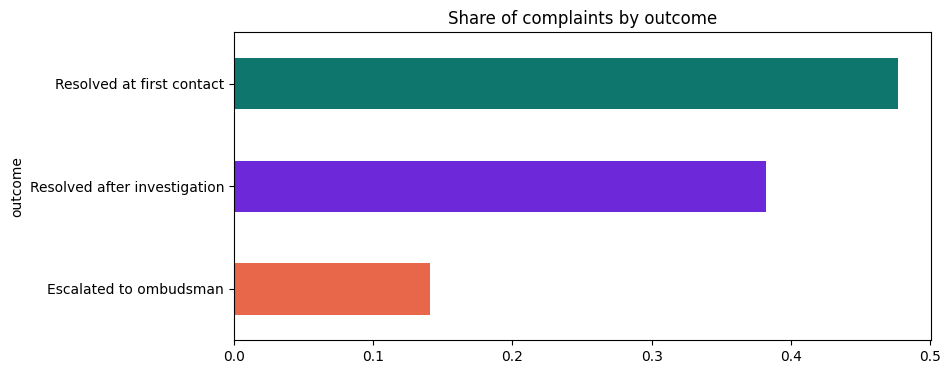

Baseline accuracy (always predict the majority class): 47.7%


In [11]:
outcome_share = df["outcome"].value_counts(normalize=True).round(3).reindex(OUTCOME_ORDER)
print(pd.concat([df["outcome"].value_counts().reindex(OUTCOME_ORDER), outcome_share], axis=1, keys=["count", "share"]))

ax = outcome_share.plot.barh(color=[OUTCOME_COLORS[o] for o in OUTCOME_ORDER], title="Share of complaints by outcome")
ax.invert_yaxis()
plt.show()
print(f"Baseline accuracy (always predict the majority class): {outcome_share.max():.1%}")

### 3.2 Distribution of the numeric features

Histograms show the shape of each variable: symmetric, skewed, bounded, with isolated values far away.

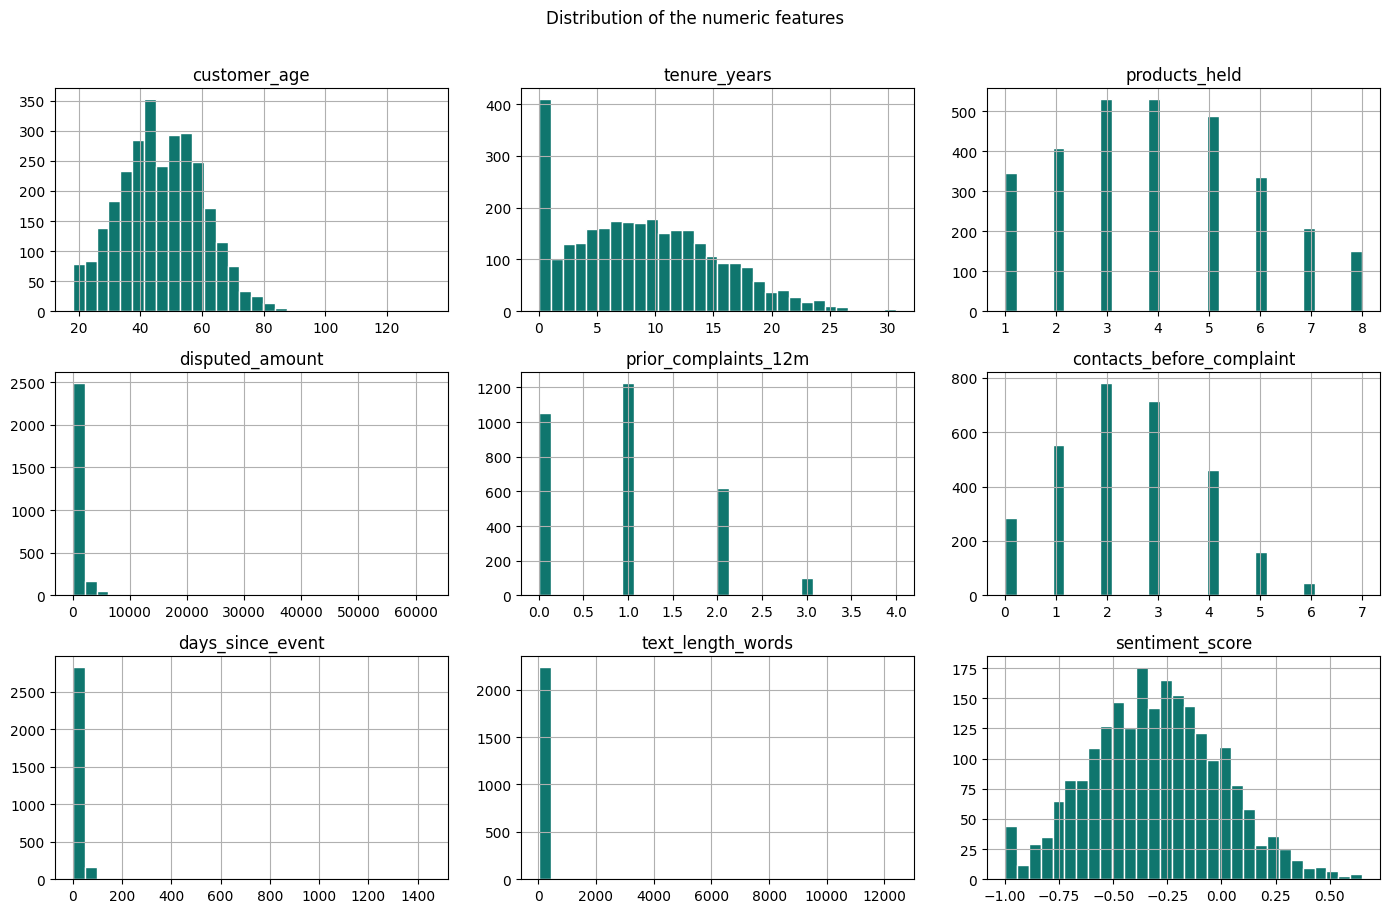

In [12]:
numeric_cols = ["customer_age", "tenure_years", "products_held", "disputed_amount", "prior_complaints_12m",
                "contacts_before_complaint", "days_since_event", "text_length_words", "sentiment_score"]

df[numeric_cols].hist(bins=30, figsize=(14, 9), color=TEAL, edgecolor="white")
plt.suptitle("Distribution of the numeric features", y=1.01)
plt.tight_layout()
plt.show()

`disputed_amount` is heavily skewed: most complaints concern a few hundred euros, a few concern tens of
thousands. On a logarithmic scale the shape becomes readable, and this is also the scale we will use for
modelling and for outlier detection on this column.

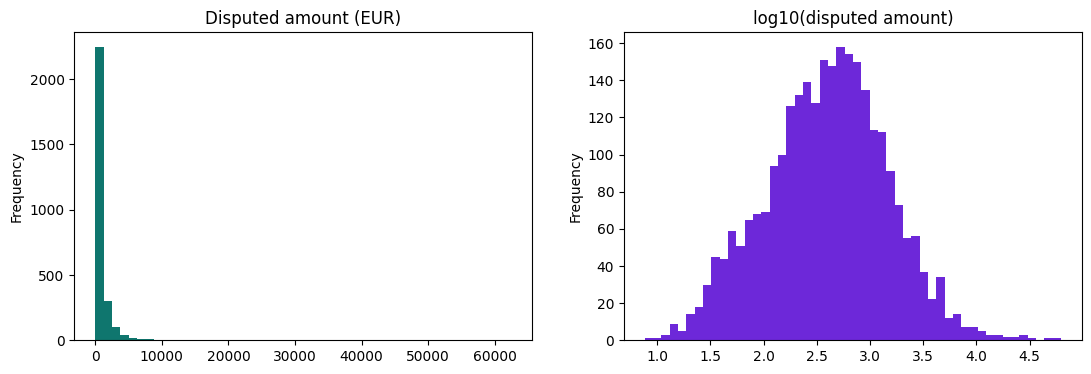

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["disputed_amount"].plot.hist(bins=50, ax=axes[0], color=TEAL, title="Disputed amount (EUR)")
np.log10(df["disputed_amount"]).plot.hist(bins=50, ax=axes[1], color=PURPLE, title="log10(disputed amount)")
plt.show()

The interactive version lets us overlay the three outcomes: the escalated complaints sit visibly to the
right (larger amounts) and to the left of the sentiment scale (more negative tone). Click a legend entry to
hide or show a class.

In [15]:
fig = px.histogram(df.assign(amount_log10=np.log10(df["disputed_amount"])), x="amount_log10", color="outcome",
                   nbins=60, barmode="overlay", opacity=0.65, category_orders={"outcome": OUTCOME_ORDER},
                   color_discrete_map=OUTCOME_COLORS, title="log10(disputed amount) by outcome")
fig.show()

fig = px.histogram(df, x="sentiment_score", color="outcome", nbins=40, barmode="overlay", opacity=0.65,
                   category_orders={"outcome": OUTCOME_ORDER}, color_discrete_map=OUTCOME_COLORS,
                   title="Sentiment score by outcome")
fig.show()

### 3.3 Categorical features and their relationship with the outcome

Bar charts of the counts first, then the share of each outcome within each category (`crosstab` with
`normalize="index"`). The second view is the one that carries business meaning.

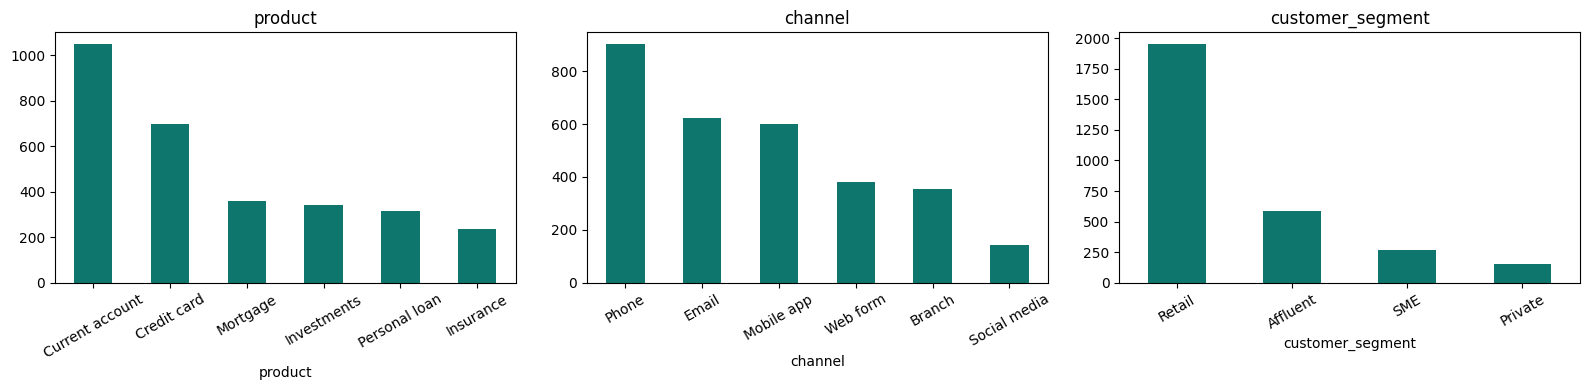

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["product", "channel", "customer_segment"]):
    df[col].value_counts().plot.bar(ax=ax, color=TEAL, title=col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [17]:
share_by_channel = pd.crosstab(df["channel"], df["outcome"], normalize="index")[OUTCOME_ORDER].round(3)
share_by_channel.sort_values("Escalated to ombudsman")

outcome,Resolved at first contact,Resolved after investigation,Escalated to ombudsman
channel,,,
Mobile app,0.642,0.287,0.072
Branch,0.499,0.372,0.130
Phone,0.450,0.415,0.135
Email,0.457,0.379,0.164
Web form,0.391,0.443,0.166
Social media,0.206,0.454,0.340


In [18]:
share_by_product = pd.crosstab(df["product"], df["outcome"], normalize="index")[OUTCOME_ORDER].round(3)
share_by_product.sort_values("Escalated to ombudsman")

outcome,Resolved at first contact,Resolved after investigation,Escalated to ombudsman
product,,,
Current account,0.587,0.325,0.088
Credit card,0.498,0.385,0.117
Personal loan,0.475,0.392,0.133
Insurance,0.376,0.447,0.177
Investments,0.311,0.455,0.235
Mortgage,0.340,0.421,0.240


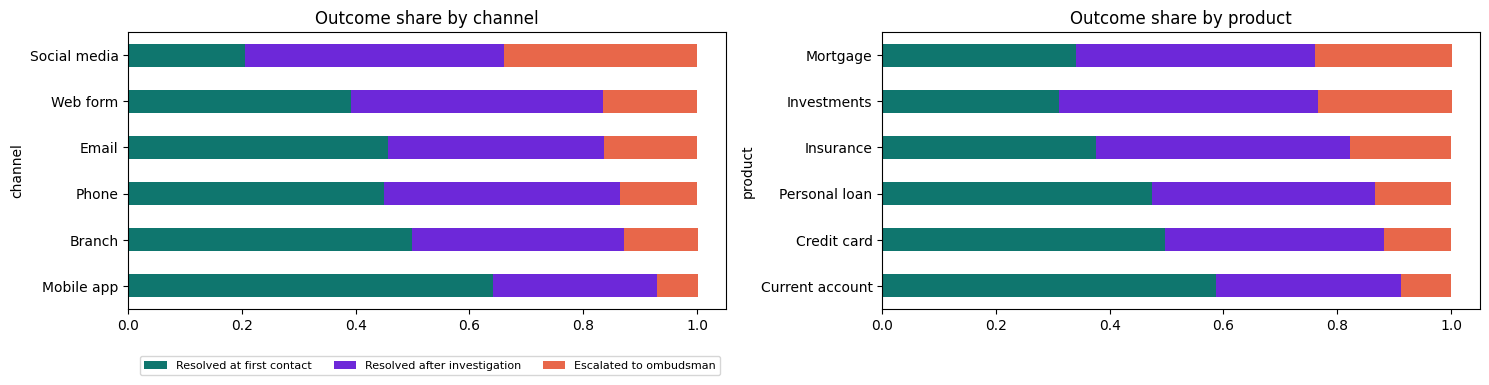

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
share_by_channel.sort_values("Escalated to ombudsman").plot.barh(stacked=True, ax=axes[0], title="Outcome share by channel",
                                                                  color=[OUTCOME_COLORS[o] for o in OUTCOME_ORDER])
share_by_product.sort_values("Escalated to ombudsman").plot.barh(stacked=True, ax=axes[1], title="Outcome share by product",
                                                                  color=[OUTCOME_COLORS[o] for o in OUTCOME_ORDER], legend=False)
axes[0].legend(bbox_to_anchor=(1.0, -0.15), ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

In [20]:
fig = px.histogram(df, x="channel", color="outcome", barnorm="percent", category_orders={"outcome": OUTCOME_ORDER},
                   color_discrete_map=OUTCOME_COLORS, title="Outcome share by channel (%)")
fig.show()

> **Business insight.** Social-media complaints escalate about a third of the time, mobile-app complaints less
> than one in ten. Investment and mortgage complaints escalate twice as often as current-account ones. The
> channel and the product are known the second a complaint arrives: a triage rule could start from here even
> without a model.
>
> **Risk.** A high escalation rate on social media may also mean that the *public* nature of the channel
> pushes the bank to settle. Correlation is not a cause: the model will learn the pattern, not the reason.

### 3.4 Complaints over time

A time series of monthly volumes is the simplest "sensor" a complaints department has. We aggregate the
dates by month with `to_period("M")` and draw a line plot.

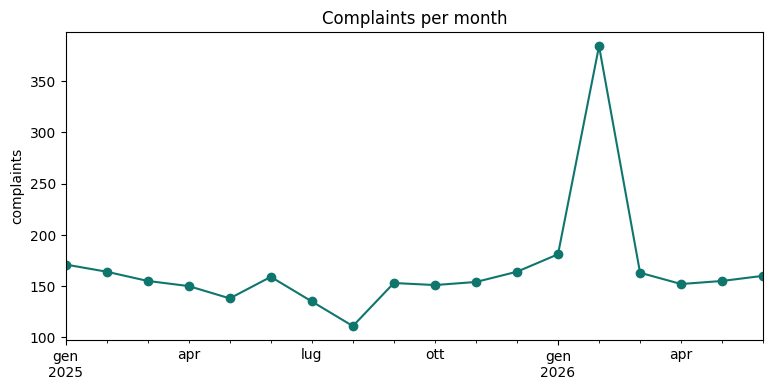

In [21]:
monthly = df.groupby(df["complaint_date"].dt.to_period("M")).size()
monthly.index = monthly.index.to_timestamp()

ax = monthly.plot.line(marker="o", color=TEAL, title="Complaints per month")
ax.set_ylabel("complaints")
ax.set_xlabel("")
plt.show()

February 2026 is more than twice the usual volume. Splitting the series by channel shows where the surge comes
from.

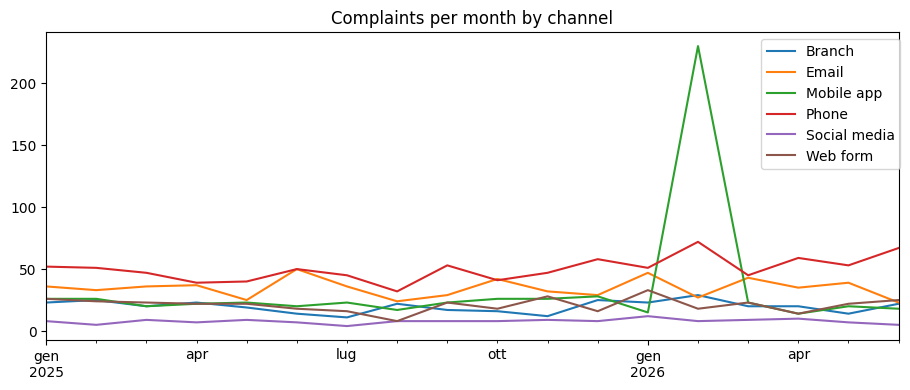

In [22]:
monthly_by_channel = df.groupby([df["complaint_date"].dt.to_period("M"), "channel"]).size().unstack(fill_value=0)
monthly_by_channel.index = monthly_by_channel.index.to_timestamp()

ax = monthly_by_channel.plot.line(figsize=(11, 4), title="Complaints per month by channel")
ax.set_xlabel("")
ax.legend(bbox_to_anchor=(1.01, 1))
plt.show()

In [23]:
long_format = monthly_by_channel.reset_index().melt(id_vars="complaint_date", var_name="channel", value_name="complaints")
fig = px.line(long_format, x="complaint_date", y="complaints", color="channel", markers=True,
              title="Complaints per month by channel (interactive)")
fig.show()

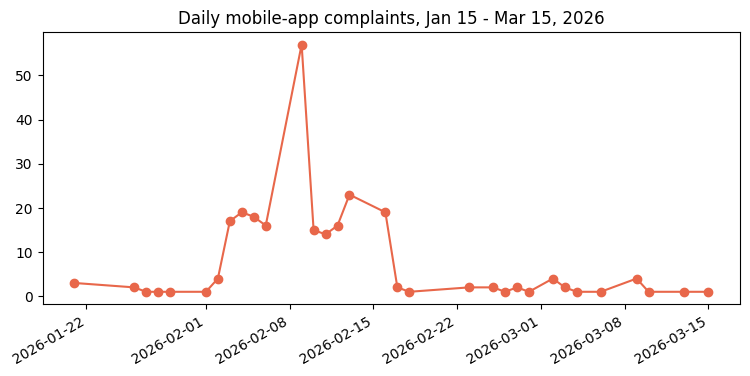

product
Current account    216
Credit card         10
Mortgage             9
Investments          7
Insurance            6
Personal loan        5
Name: count, dtype: int64

In [24]:
# zoom on the surge: daily complaints through the mobile app around February 2026
window = df[(df["channel"] == "Mobile app") & df["complaint_date"].between("2026-01-15", "2026-03-15")]
daily = window.groupby("complaint_date").size()

ax = daily.plot.line(marker="o", color=CORAL, title="Daily mobile-app complaints, Jan 15 - Mar 15, 2026")
ax.set_xlabel("")
plt.show()
window["product"].value_counts()

> **Business insight.** Between 3 and 14 February 2026 the mobile app generated a burst of current-account
> complaints: an operational incident (an outage, a duplicated-payment bug). Volume monitoring would have
> raised the alarm on day two.
>
> **Risk for the model.** Those 200 complaints are atypical (small amounts, quickly resolved). A model trained
> on a period with an incident learns the incident too. When we deploy, we must watch for **drift**: the
> data the model sees in production may not look like the data it was trained on.

### 3.5 Relationships between features

Box plots by outcome show which numeric features separate the classes; the correlation matrix and the scatter
matrix show how the features move together.

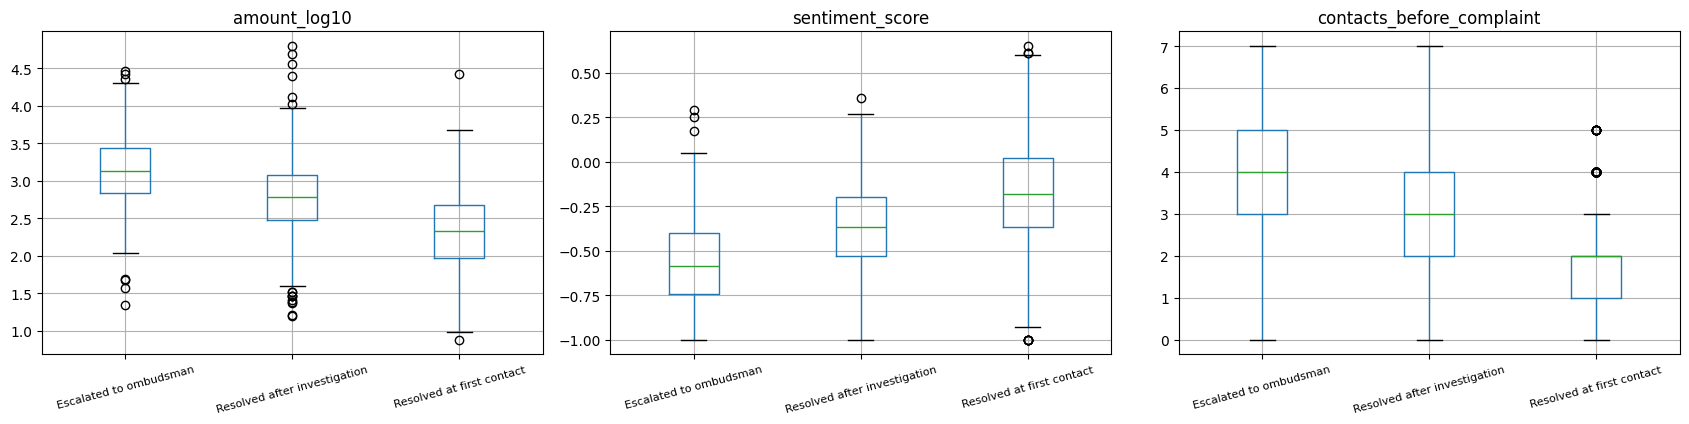

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
df.assign(amount_log10=np.log10(df["disputed_amount"])).boxplot(column="amount_log10", by="outcome", ax=axes[0])
df.boxplot(column="sentiment_score", by="outcome", ax=axes[1])
df.boxplot(column="contacts_before_complaint", by="outcome", ax=axes[2])
for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15, labelsize=8)
plt.suptitle("")
plt.tight_layout()
plt.show()

In [26]:
fig = px.box(df, x="outcome", y="disputed_amount", color="outcome", log_y=True, hover_data=["complaint_id", "product", "customer_segment"],
             category_orders={"outcome": OUTCOME_ORDER}, color_discrete_map=OUTCOME_COLORS,
             title="Disputed amount by outcome (log scale)")
fig.show()

**Correlation matrix.** We use the logarithm of the amount, otherwise its long tail would hide the linear
relationships. Values close to +1 or −1 indicate features that move together.

In [27]:
num = df[numeric_cols].copy()
num["disputed_amount"] = np.log10(num["disputed_amount"])
num = num.rename(columns={"disputed_amount": "disputed_amount_log10"})

corr = num.corr().round(2)
corr

,customer_age,tenure_years,products_held,disputed_amount_log10,prior_complaints_12m,contacts_before_complaint,days_since_event,text_length_words,sentiment_score
customer_age,1.00,0.63,0.60,0.21,0.01,0.03,0.03,0.04,0.05
tenure_years,0.63,1.00,0.87,0.17,0.01,0.02,0.03,0.06,0.02
products_held,0.60,0.87,1.00,0.21,0.01,0.01,0.03,0.06,0.02
disputed_amount_log10,0.21,0.17,0.21,1.00,0.42,0.52,0.29,0.09,-0.29
prior_complaints_12m,0.01,0.01,0.01,0.42,1.00,0.53,0.25,0.07,-0.44
contacts_before_complaint,0.03,0.02,0.01,0.52,0.53,1.00,0.27,0.08,-0.43
days_since_event,0.03,0.03,0.03,0.29,0.25,0.27,1.00,0.12,-0.34
text_length_words,0.04,0.06,0.06,0.09,0.07,0.08,0.12,1.00,-0.12
sentiment_score,0.05,0.02,0.02,-0.29,-0.44,-0.43,-0.34,-0.12,1.00


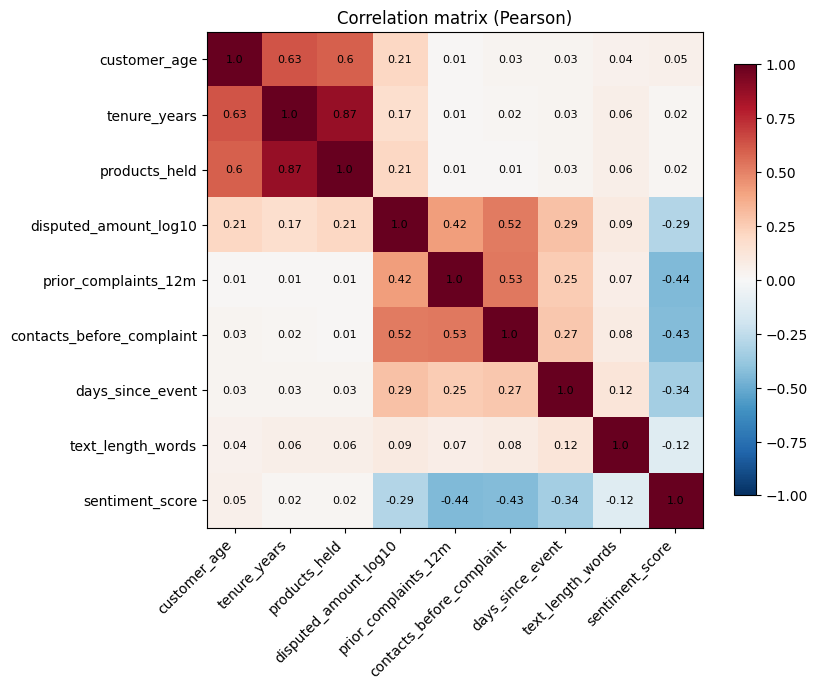

In [28]:
fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, corr.values[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(image, shrink=0.8)
ax.set_title("Correlation matrix (Pearson)")
plt.show()

In [29]:
fig = px.imshow(corr, text_auto=True, color_continuous_scale="RdBu_r", zmin=-1, zmax=1, aspect="auto",
                title="Correlation matrix (interactive)")
fig.update_layout(height=600)
fig.show()

> **Business insight.** A "severity" cluster stands out: larger amounts, more negative sentiment, more contacts
> before the complaint and more previous complaints move together. They are symptoms of the same thing: a
> customer with a serious, unresolved problem. Age, tenure and number of products form a second, unrelated
> cluster.
>
> **Something does not add up.** `text_length_words` and `days_since_event` are almost uncorrelated with the
> rest of the severity cluster, although the box plots by outcome suggested otherwise. Pearson's correlation is
> fragile: a handful of extreme values can flatten it. A quick check with the rank-based Spearman correlation,
> which is immune to extreme values, tells a different story. We will come back to this in section 5.

**Scatter plots and the scatter matrix.** Two variables at a time. With the interactive version we can
hover on any point to read its `complaint_id`, which will be useful in the outlier section.

In [30]:
# Spearman correlation works on ranks, so a few extreme values cannot distort it
num.corr(method="spearman").round(2).loc[["text_length_words", "days_since_event"], ["disputed_amount_log10", "sentiment_score", "contacts_before_complaint", "prior_complaints_12m"]]

,disputed_amount_log10,sentiment_score,contacts_before_complaint,prior_complaints_12m
text_length_words,0.54,-0.41,0.56,0.51
days_since_event,0.63,-0.34,0.54,0.46


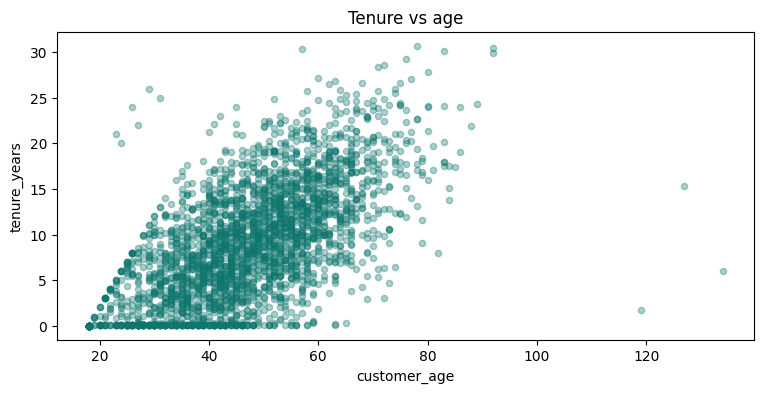

In [31]:
ax = df.plot.scatter(x="customer_age", y="tenure_years", alpha=0.35, color=TEAL, title="Tenure vs age")
plt.show()

fig = px.scatter(df, x="disputed_amount", y="sentiment_score", color="outcome", log_x=True, opacity=0.6,
                 hover_data=["complaint_id", "product", "channel"], category_orders={"outcome": OUTCOME_ORDER},
                 color_discrete_map=OUTCOME_COLORS, title="Sentiment vs disputed amount, by outcome")
fig.show()

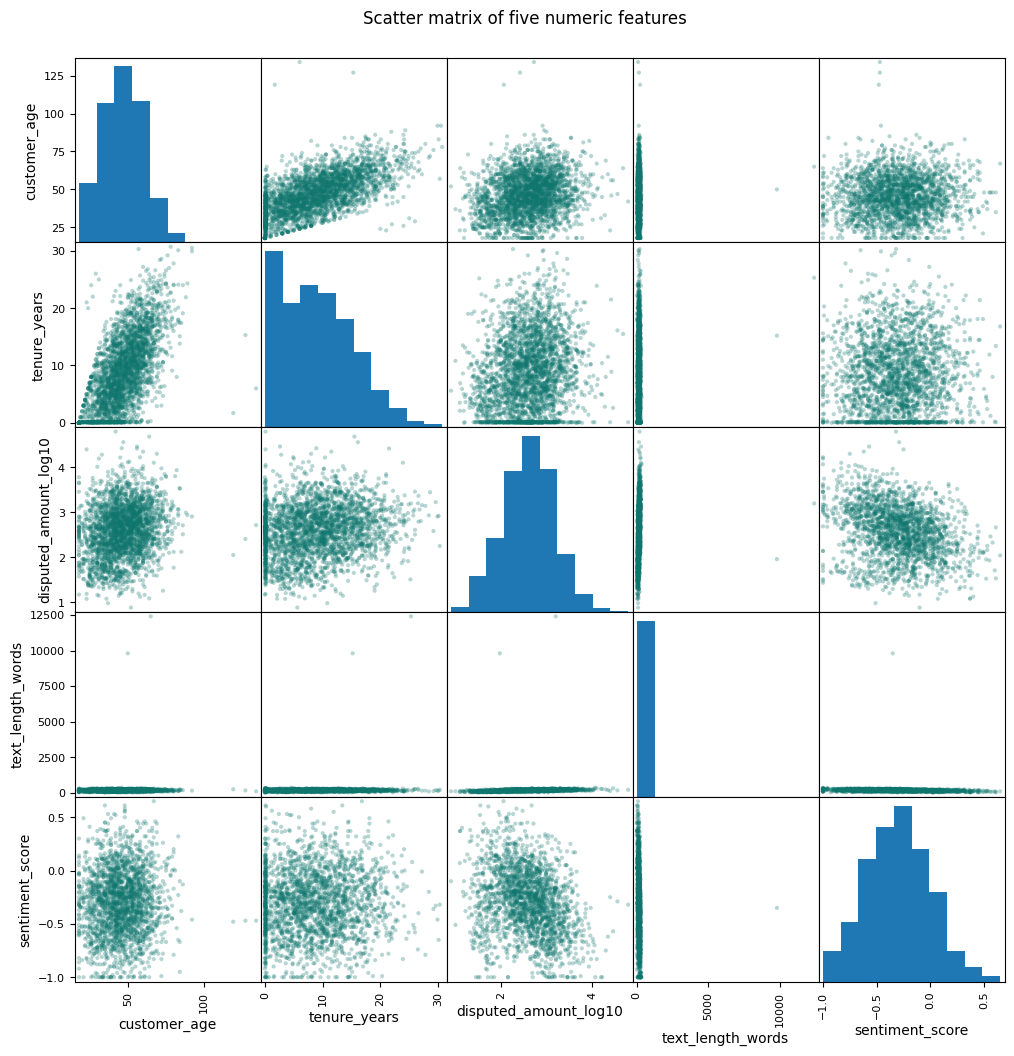

In [32]:
from pandas.plotting import scatter_matrix

scatter_matrix(num[["customer_age", "tenure_years", "disputed_amount_log10", "text_length_words", "sentiment_score"]],
               figsize=(12, 12), alpha=0.3, diagonal="hist", color=TEAL)
plt.suptitle("Scatter matrix of five numeric features", y=0.92)
plt.show()

In [33]:
fig = px.scatter_matrix(num.join(df[["outcome", "complaint_id"]]),
                        dimensions=["disputed_amount_log10", "text_length_words", "sentiment_score", "contacts_before_complaint"],
                        color="outcome", opacity=0.5, hover_data=["complaint_id"],
                        category_orders={"outcome": OUTCOME_ORDER}, color_discrete_map=OUTCOME_COLORS,
                        title="Scatter matrix, coloured by outcome (interactive)")
fig.update_traces(diagonal_visible=False, marker=dict(size=3))
fig.update_layout(height=750)
fig.show()

## 4. Missing values

### 4.1 How much is missing, and where

`isna()` returns True for every missing cell. Summing it by column gives the count; taking the mean gives the
share.

In [34]:
missing = pd.concat([df.isna().sum(), df.isna().mean().round(3)], axis=1, keys=["missing", "share"])
missing[missing["missing"] > 0]

,missing,share
customer_segment,40,0.013
customer_age,122,0.041
disputed_amount,249,0.083
text_length_words,758,0.253
sentiment_score,759,0.253


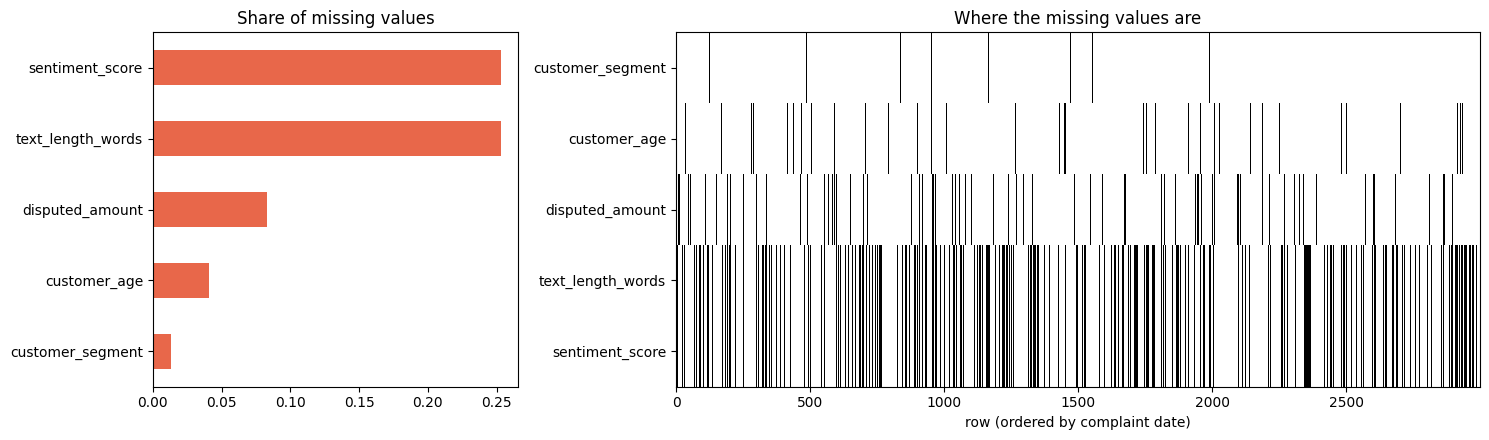

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1, 2.2]})
missing.loc[missing["missing"] > 0, "share"].sort_values().plot.barh(ax=axes[0], color=CORAL, title="Share of missing values")

# "missingness map": one column per row of the dataset, one line per column; dark = missing
cols_with_missing = missing.index[missing["missing"] > 0]
axes[1].imshow(df[cols_with_missing].isna().T, aspect="auto", cmap="Greys", interpolation="nearest")
axes[1].set_yticks(range(len(cols_with_missing)))
axes[1].set_yticklabels(cols_with_missing)
axes[1].set_xlabel("row (ordered by complaint date)")
axes[1].set_title("Where the missing values are")
plt.tight_layout()
plt.show()

Notice that `sentiment_score` and `text_length_words` are missing on the *same* rows: the two features come from
the same source, the complaint text. When there is no text, both are blank.

### 4.2 Why values are missing: three mechanisms

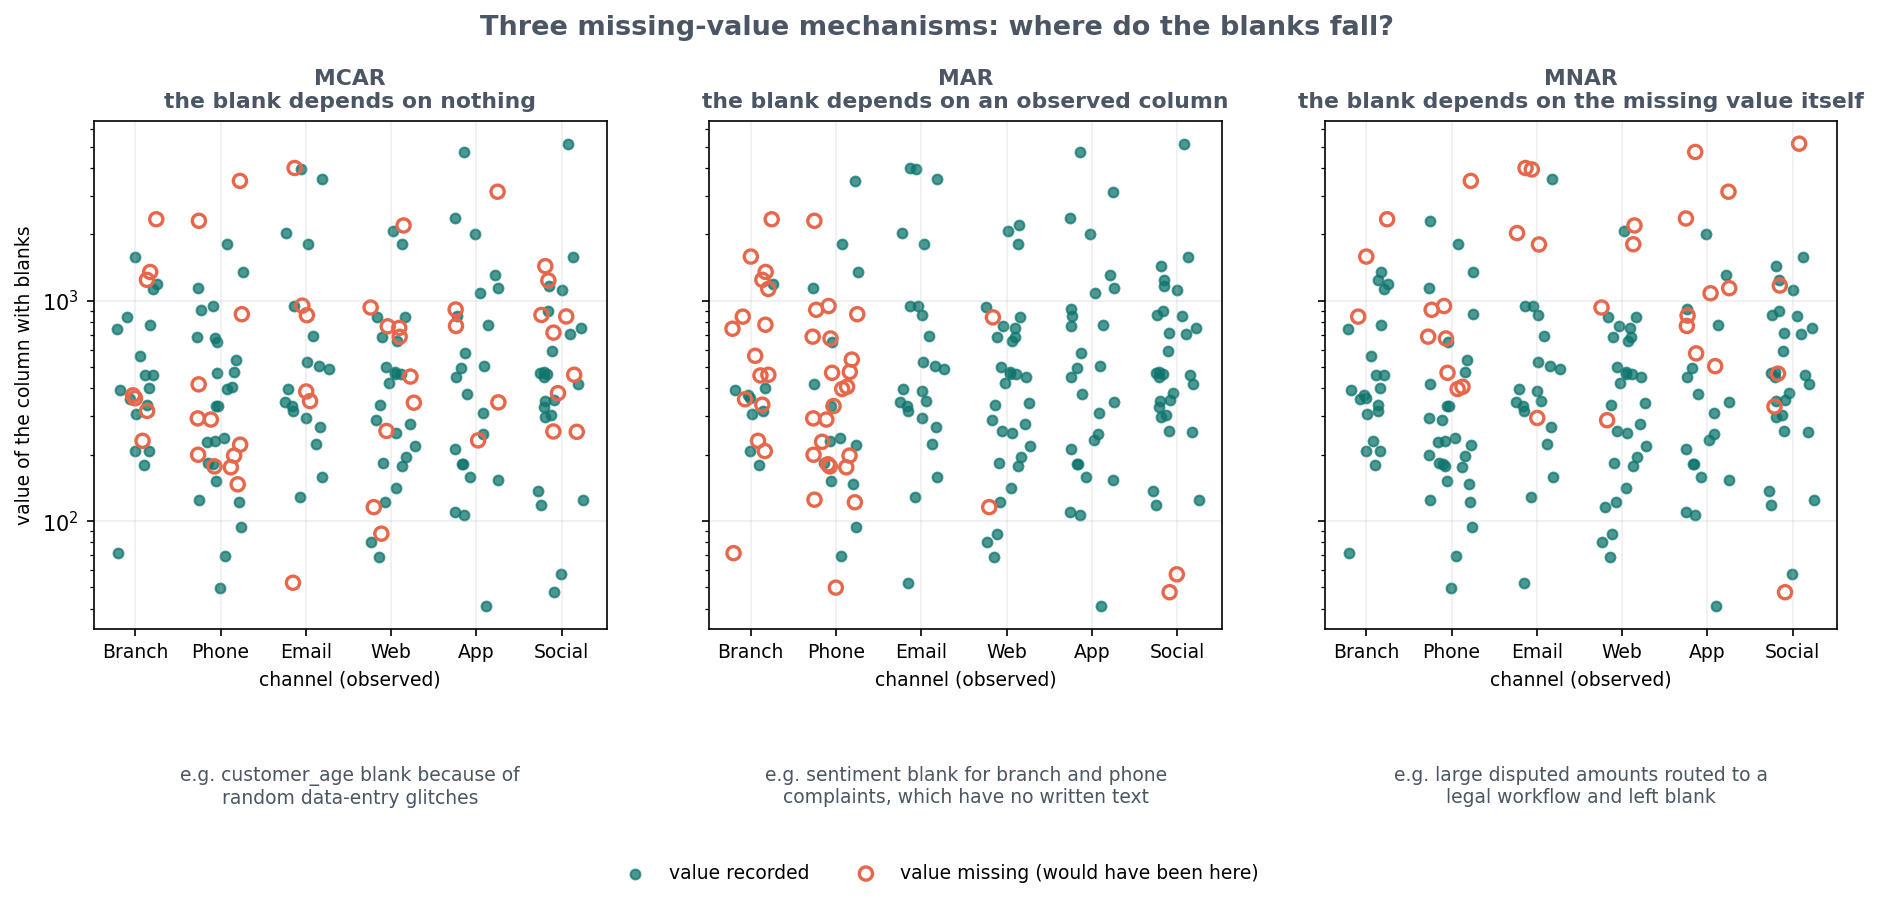

The statistical literature distinguishes three mechanisms, and the distinction is practical, because it decides
which handling strategies are safe.

| Mechanism | Definition | Example in this dataset | Consequence |
|---|---|---|---|
| **MCAR** — missing completely at random | the probability of a blank does not depend on anything, observed or not | `customer_age` blank because of random data-entry glitches | dropping or imputing the rows is unbiased; we only lose some information |
| **MAR** — missing at random | the probability of a blank depends on *other observed* columns | text features blank mostly for branch and phone complaints, which have no written text | imputation can use the observed columns; a "text available" flag preserves the information |
| **MNAR** — missing not at random | the probability of a blank depends on the *missing value itself* | `disputed_amount` blank more often when the amount is large (large claims go to a separate legal workflow) | any imputation is biased; the blank is itself informative and should become a feature |

We cannot prove the mechanism from the data alone, but we can look for evidence.

In [36]:
# Evidence of MCAR: the share of blank ages is roughly the same in every channel and every segment
print("Missing customer_age by channel:")
print(df["customer_age"].isna().groupby(df["channel"]).mean().round(3), "\n")
print("Missing customer_age by segment:")
print(df["customer_age"].isna().groupby(df["customer_segment"]).mean().round(3))

Missing customer_age by channel:
channel
Branch          0.034
Email           0.043
Mobile app      0.032
Phone           0.054
Social media    0.021
Web form        0.032
Name: customer_age, dtype: float64 

Missing customer_age by segment:
customer_segment
Affluent    0.032
Private     0.058
Retail      0.039
SME         0.057
Name: customer_age, dtype: float64


In [37]:
# Evidence of MAR: blank sentiment depends on an observed column, the channel
df["sentiment_score"].isna().groupby(df["channel"]).mean().round(3).sort_values()

channel
Social media    0.007
Web form        0.013
Mobile app      0.027
Email           0.030
Phone           0.571
Branch          0.572
Name: sentiment_score, dtype: float64

In [38]:
# Evidence of MNAR: we cannot see the blank amounts, but complaints with a blank amount escalate far more often
# and receive a much higher compensation at closure - a sign that these were the large claims
print(df.groupby(df["disputed_amount"].isna())["outcome"].value_counts(normalize=True).round(3).unstack()[OUTCOME_ORDER], "\n")
print("Median compensation, by whether the amount is blank:")
print(df.groupby(df["disputed_amount"].isna())["compensation_eur"].median())

outcome          Resolved at first contact  Resolved after investigation  Escalated to ombudsman
disputed_amount                                                                                 
False                                0.498                         0.376                   0.126
True                                 0.241                         0.446                   0.313 

Median compensation, by whether the amount is blank:
disputed_amount
False      0.00
True     433.21
Name: compensation_eur, dtype: float64


> **Business insight.** A blank field is not the absence of information. Here the blank amount is one of the
> best predictors of escalation, because the *process* that leaves it blank (the legal workflow) is itself
> the process that handles the serious cases. Before "fixing" missing data, ask the people who run the process
> why the field is empty.

### 4.3 Handling strategies

Four strategies, from the simplest to the most sophisticated. We try each on our data to see its effect.

**a) Delete the rows** (`dropna`). Simple and honest, but expensive: with several columns affected we lose
a large share of the data, and if the mechanism is not MCAR we also bias what remains.

In [39]:
print("Rows with at least one missing value:", df.isna().any(axis=1).sum(), "of", len(df))
print("Rows left after dropna():", len(df.dropna()))

Rows with at least one missing value: 1042 of 3000
Rows left after dropna(): 1958


**b) Fill with a constant summary**: the mean or the median for numeric columns, the most frequent value
(mode) for categorical ones. The median is preferred for skewed columns such as the amount, where the mean is
pulled up by the long tail.

In [40]:
print(f"disputed_amount   mean = {df['disputed_amount'].mean():8.1f}   median = {df['disputed_amount'].median():8.1f}")
print(f"customer_age      mean = {df['customer_age'].mean():8.1f}   median = {df['customer_age'].median():8.1f}")
print(f"sentiment_score   mean = {df['sentiment_score'].mean():8.2f}   median = {df['sentiment_score'].median():8.2f}")
print("customer_segment  mode =", df["customer_segment"].mode()[0])

disputed_amount   mean =    959.1   median =    417.3
customer_age      mean =     46.9   median =     46.0
sentiment_score   mean =    -0.30   median =    -0.30
customer_segment  mode = Retail


Filling with a constant has a visible side effect: it creates a spike in the distribution at the filled value.
For the text features this spike would contain 25% of the rows.

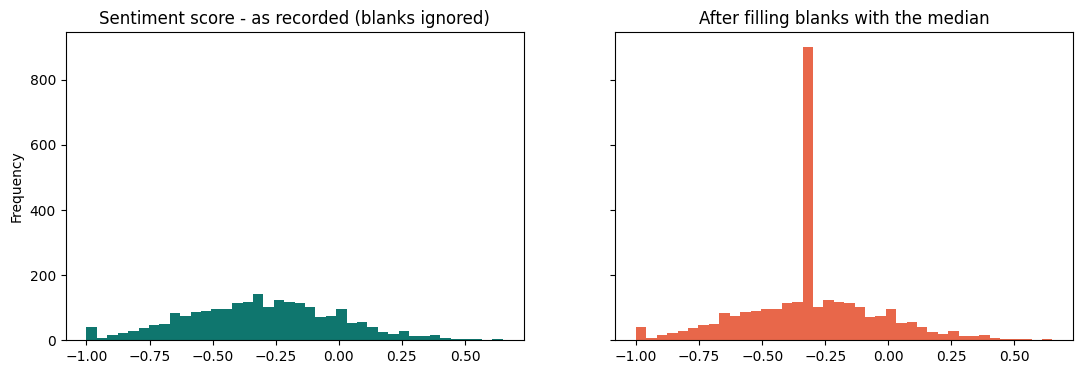

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
df["sentiment_score"].plot.hist(bins=40, ax=axes[0], color=TEAL, title="Sentiment score - as recorded (blanks ignored)")
df["sentiment_score"].fillna(df["sentiment_score"].median()).plot.hist(bins=40, ax=axes[1], color=CORAL, title="After filling blanks with the median")
plt.show()

**c) Impute with a model.** Predict the missing value from the other columns. For the age we can train a small
regression model on the rows where the age is known, using tenure and number of products as inputs, and use it
to fill the rows where the age is blank. The imputed values are then spread realistically instead of piling up
on one number.

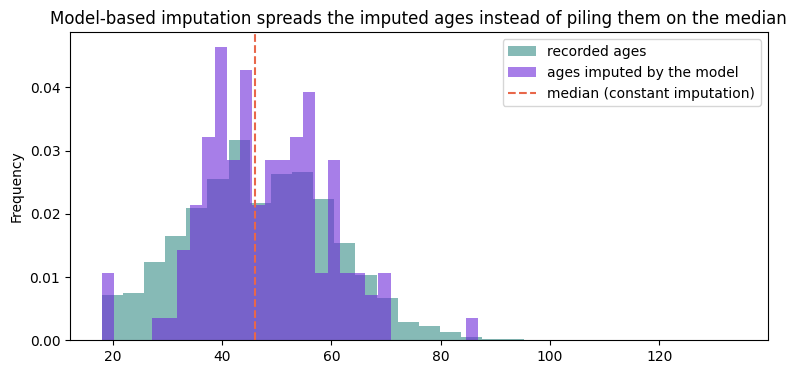

In [42]:
from sklearn.ensemble import RandomForestRegressor

known = df["customer_age"].notna()
age_model = RandomForestRegressor(n_estimators=200, random_state=42)
age_model.fit(df.loc[known, ["tenure_years", "products_held"]], df.loc[known, "customer_age"])

age_from_model = age_model.predict(df.loc[~known, ["tenure_years", "products_held"]])

fig, ax = plt.subplots(figsize=(9, 4))
df.loc[known, "customer_age"].plot.hist(bins=30, ax=ax, color=TEAL, alpha=0.5, density=True, label="recorded ages")
pd.Series(age_from_model).plot.hist(bins=30, ax=ax, color=PURPLE, alpha=0.6, density=True, label="ages imputed by the model")
ax.axvline(df["customer_age"].median(), color=CORAL, linestyle="--", label="median (constant imputation)")
ax.legend()
ax.set_title("Model-based imputation spreads the imputed ages instead of piling them on the median")
plt.show()

**d) Add a missing indicator.** A new 0/1 column that records *whether* the value was missing. It costs
nothing and, for MAR and MNAR columns, it keeps the information carried by the blank itself. We will use it for
the amount (MNAR) and for the text features (MAR).

### 4.4 Our decisions

| Column | Mechanism | Decision |
|---|---|---|
| `customer_age` | MCAR | median (simple; the model-based version is an option if age matters) |
| `sentiment_score`, `text_length_words` | MAR | median **plus** a `text_available` indicator |
| `disputed_amount` | MNAR | median **plus** an `amount_missing` indicator |
| `customer_segment` | text "unknown" | its own category, `Unknown` |

We apply the decisions in section 6, *after* the outlier analysis: an extreme value would distort the medians
we impute with.

## 5. Outliers

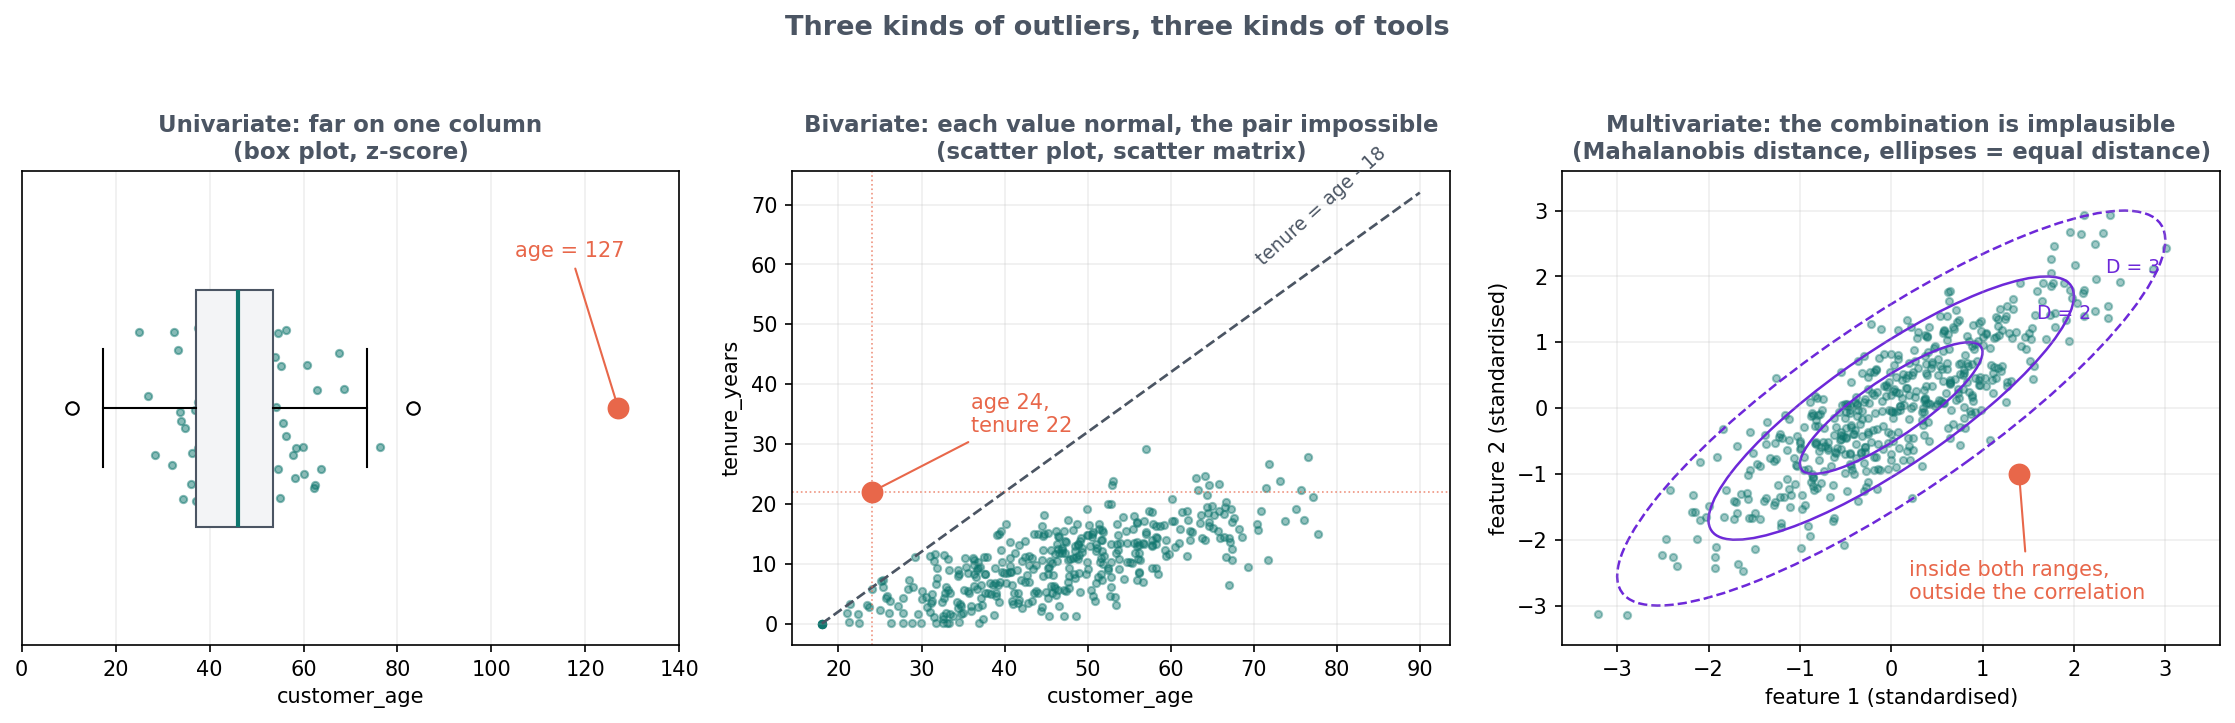

An outlier is an observation far from the others. The interesting question is *far in which sense*:

- **univariate**: far on one column alone (box plot, z-score);
- **bivariate**: normal on each column, but an impossible or unusual *pair* (scatter plot, scatter matrix);
- **multivariate**: normal on every column and every pair, but an implausible *combination* of many columns
  (Mahalanobis distance).

And the second question is *what to do with it*: an error to correct or remove, a rare but genuine case to
keep, or a signal to investigate (fraud, a broken process).

### 5.1 Box plots and the 1.5 × IQR rule

The box spans the first to the third quartile (the interquartile range, IQR); the whiskers extend 1.5 × IQR
beyond the box; anything further is drawn as a point.

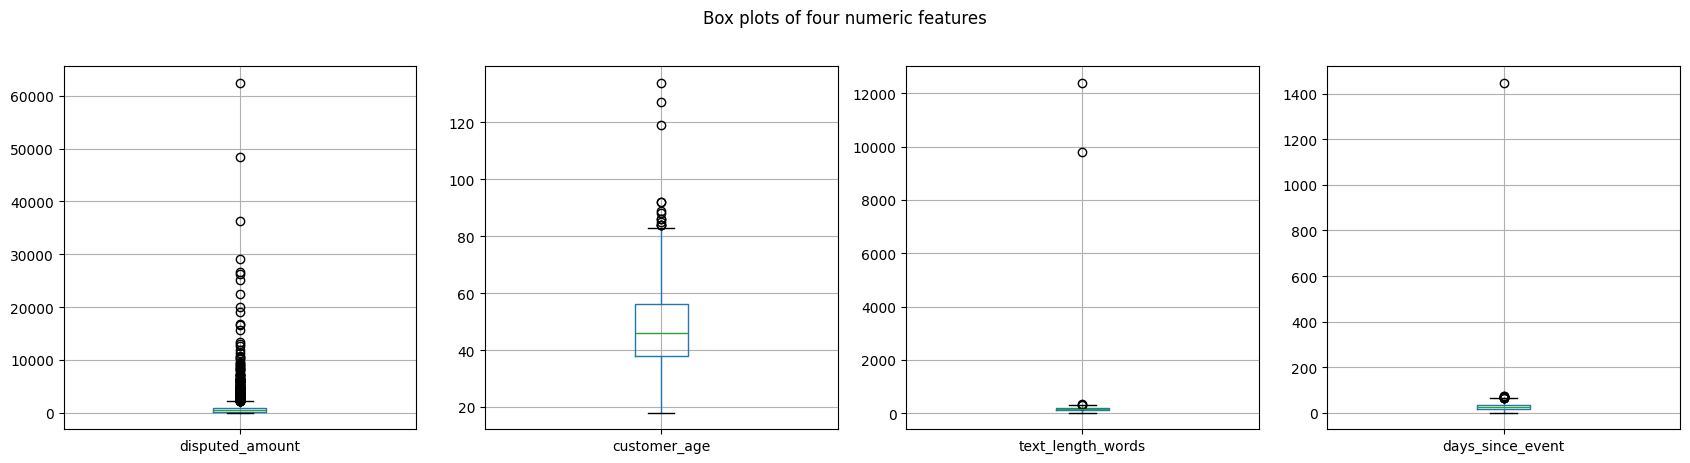

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))
for ax, col in zip(axes, ["disputed_amount", "customer_age", "text_length_words", "days_since_event"]):
    df.boxplot(column=col, ax=ax)
plt.suptitle("Box plots of four numeric features", y=1.02)
plt.tight_layout()
plt.show()

In [44]:
col = "disputed_amount"
q1, q3 = df[col].quantile([0.25, 0.75])
upper_whisker = q3 + 1.5 * (q3 - q1)
print(f"{col}: Q1 = {q1:.0f}, Q3 = {q3:.0f}, IQR = {q3 - q1:.0f}, upper whisker = {upper_whisker:.0f}")
print("Rows above the upper whisker:", (df[col] > upper_whisker).sum())

disputed_amount: Q1 = 169, Q3 = 959, IQR = 790, upper whisker = 2145
Rows above the upper whisker: 252


Two hundred and fifty "outliers" is not a list anyone can investigate, and most of them are legitimate large
claims from private-banking and investment customers. On a skewed variable the 1.5 × IQR rule must be applied
on the log scale; then the list becomes short.

In [45]:
amount_log10 = np.log10(df["disputed_amount"])
q1, q3 = amount_log10.quantile([0.25, 0.75])
upper_log = q3 + 1.5 * (q3 - q1)
print("Rows above the upper whisker on the log scale:", (amount_log10 > upper_log).sum())

df.loc[amount_log10 > upper_log, ["complaint_id", "customer_segment", "product", "disputed_amount", "outcome"]].sort_values("disputed_amount", ascending=False)

Rows above the upper whisker on the log scale: 14


,complaint_id,customer_segment,product,disputed_amount,outcome
158,CMP-000159,Retail,Credit card,62514.00,Resolved after investigation
591,CMP-000592,Retail,Current account,48467.00,Resolved after investigation
515,CMP-000516,Retail,Current account,36332.00,Resolved after investigation
2734,CMP-002735,Private,Mortgage,29090.20,Escalated to ombudsman
1825,CMP-001826,Retail,Personal loan,26716.00,Resolved at first contact
2491,CMP-002492,Retail,Investments,26235.21,Escalated to ombudsman
1243,CMP-001244,Retail,Current account,25090.00,Resolved after investigation
746,CMP-000747,Private,Investments,22415.64,Escalated to ombudsman
1867,CMP-001868,Affluent,Investments,20062.23,Escalated to ombudsman
1376,CMP-001377,Affluent,Insurance,19134.87,Escalated to ombudsman


Read the amounts: five of them end in `.00` and belong to retail customers with a current account, a credit
card or a personal loan. They are exactly 100 times a plausible amount: cents keyed as euros. The others are
large but credible (mortgages, investments, private-banking customers).

The interactive box plot by segment makes the same point: hover on the extreme points to read the
`complaint_id`.

In [46]:
fig = px.box(df.dropna(subset=["customer_segment"]), x="customer_segment", y="disputed_amount", log_y=True, color="customer_segment",
             hover_data=["complaint_id", "product"], title="Disputed amount by segment (log scale) - hover on the extreme points")
fig.show()

### 5.2 The z-score

The z-score measures how many standard deviations a value is from the column mean. A common rule flags
|z| > 3. It is quick and works on every numeric column at once, with two caveats: it assumes a roughly
symmetric distribution (use the log for the amount), and an extreme value inflates the standard deviation and
can hide, or "mask", other outliers.

In [47]:
z = (num - num.mean()) / num.std()           # `num` already has the amount on the log10 scale
z_flags = z.abs() > 3
print("Rows with |z| > 3, per column:")
print(z_flags.sum())

Rows with |z| > 3, per column:
customer_age                 7
tenure_years                 9
products_held                0
disputed_amount_log10        8
prior_complaints_12m         5
contacts_before_complaint    6
days_since_event             1
text_length_words            2
sentiment_score              3
dtype: int64


In [48]:
for col in ["customer_age", "text_length_words", "days_since_event", "disputed_amount_log10"]:
    rows = df.loc[z_flags[col], ["complaint_id", col.replace("_log10", "")]]
    print(f"\n{col}: {len(rows)} rows")
    print(rows.to_string(index=False))


customer_age: 7 rows
complaint_id  customer_age
  CMP-000502          89.0
  CMP-000842          92.0
  CMP-001096          88.0
  CMP-001791          92.0
  CMP-001855         119.0
  CMP-002877         134.0
  CMP-002901         127.0

text_length_words: 2 rows
complaint_id  text_length_words
  CMP-000891            12400.0
  CMP-002408             9800.0

days_since_event: 1 rows
complaint_id  days_since_event
  CMP-001223            1450.0

disputed_amount_log10: 8 rows
complaint_id  disputed_amount
  CMP-000159         62514.00
  CMP-000516         36332.00
  CMP-000592         48467.00
  CMP-000747         22415.64
  CMP-001244         25090.00
  CMP-001826         26716.00
  CMP-002492         26235.21
  CMP-002735         29090.20


> **Reading the list.** A flag is a question, not a verdict. Ages of 119–134 are impossible, ages of 88–92 are
> simply old customers. A complaint of 12,400 words is a pasted document; an event four years old may be
> genuine but is worth a look. On the log scale the z-score finds the same amounts as the box plot; on the *raw*
> amount it would have flagged only the very largest values, so the transformation matters more than the
> threshold. The flags on the count columns (contacts, prior complaints) are the natural tail of a discrete
> variable and would be released after a glance.

### 5.3 Scatter plots: outliers that live in a pair of columns

Age and tenure are individually well-behaved. Plotting one against the other reveals a physical constraint:
nobody can have been a customer for longer than their adult life, so every point must lie below the line
`tenure = age − 18`.

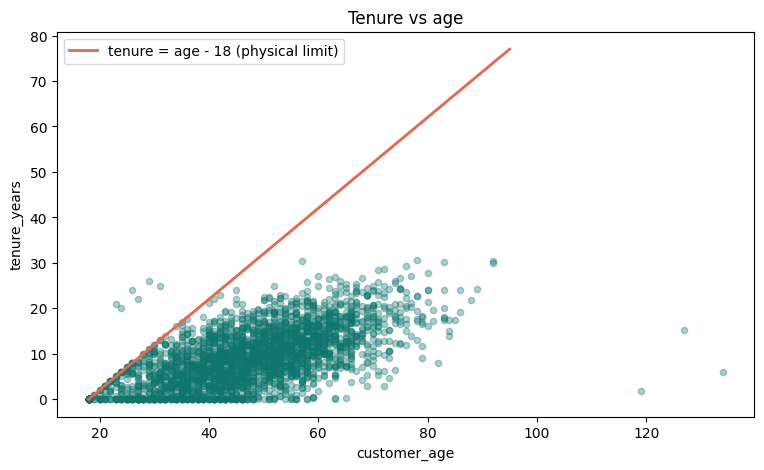

In [49]:
ax = df.plot.scatter(x="customer_age", y="tenure_years", alpha=0.35, color=TEAL, figsize=(9, 5), title="Tenure vs age")
ax.plot([18, 95], [0, 77], color=CORAL, linewidth=2, label="tenure = age - 18 (physical limit)")
ax.legend()
plt.show()

In [50]:
fig = px.scatter(df, x="customer_age", y="tenure_years", opacity=0.5, hover_data=["complaint_id", "products_held"],
                 title="Tenure vs age (interactive) - hover on the points above the diagonal")
fig.show()

In [51]:
impossible_tenure = df["tenure_years"] > df["customer_age"] - 18
print("Rows with tenure longer than adult life:", impossible_tenure.sum())
df.loc[impossible_tenure, ["complaint_id", "customer_age", "tenure_years", "products_held"]]

Rows with tenure longer than adult life: 6


,complaint_id,customer_age,tenure_years,products_held
631,CMP-000632,29.0,26.0,7.0
656,CMP-000657,26.0,24.0,3.0
1953,CMP-001954,24.0,20.0,5.0
2005,CMP-002006,27.0,22.0,1.0
2644,CMP-002645,31.0,25.0,5.0
2673,CMP-002674,23.0,21.0,5.0


### 5.4 The scatter matrix: many pairs at once

With nine numeric columns there are 36 pairs. The scatter matrix draws them all; we look for points that sit
away from the cloud in *some* panel. Here a small group of customers with a few months of tenure and 7–8
products stands out in the `tenure_years` / `products_held` panel: either a data-entry error or a customer
migrated from another bank, both worth checking.

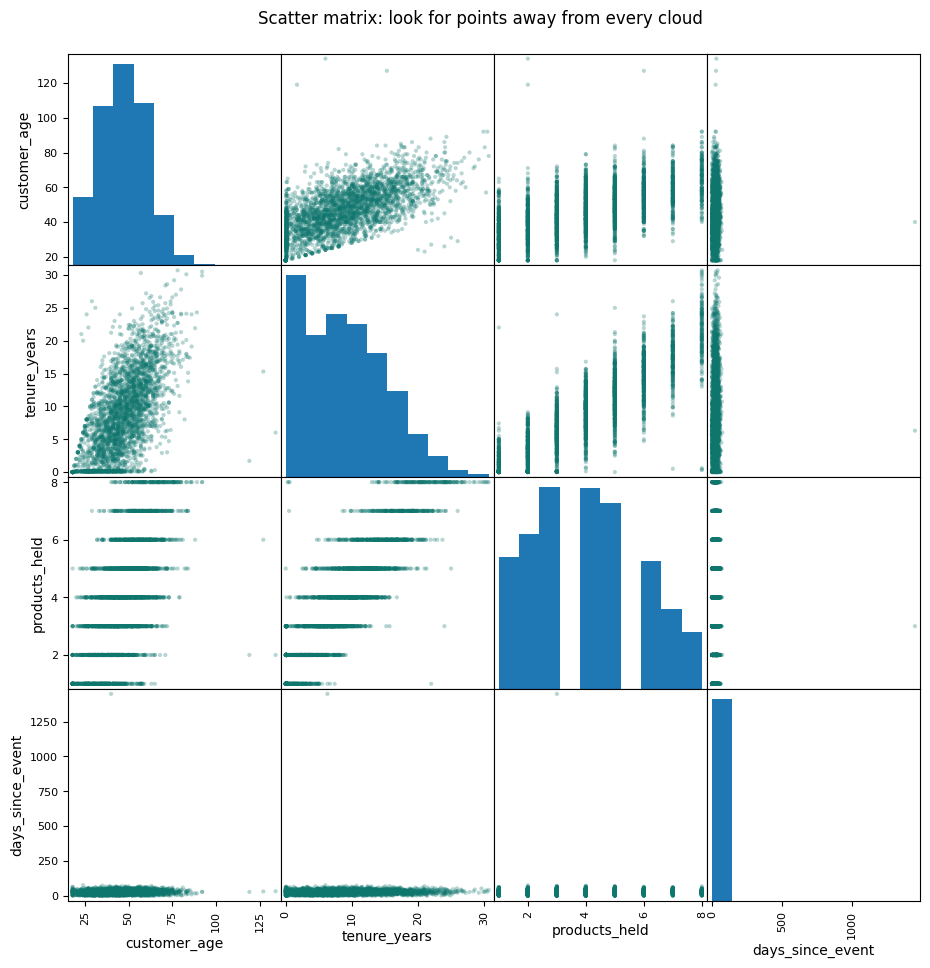

In [52]:
scatter_matrix(df[["customer_age", "tenure_years", "products_held", "days_since_event"]],
               figsize=(11, 11), alpha=0.3, diagonal="hist", color=TEAL)
plt.suptitle("Scatter matrix: look for points away from every cloud", y=0.92)
plt.show()

In [53]:
fig = px.scatter_matrix(df, dimensions=["customer_age", "tenure_years", "products_held", "days_since_event"],
                        opacity=0.4, hover_data=["complaint_id"], title="Scatter matrix (interactive)")
fig.update_traces(diagonal_visible=False, marker=dict(size=3, color=TEAL))
fig.update_layout(height=700)
fig.show()

In [54]:
new_with_many_products = (df["tenure_years"] < 1) & (df["products_held"] >= 7)
print("New customers with 7 or more products:", new_with_many_products.sum())
df.loc[new_with_many_products, ["complaint_id", "customer_age", "tenure_years", "products_held", "customer_segment"]]

New customers with 7 or more products: 4


,complaint_id,customer_age,tenure_years,products_held,customer_segment
356,CMP-000357,55.0,0.4,8.0,Private
649,CMP-000650,42.0,0.3,8.0,Retail
1977,CMP-001978,53.0,0.6,8.0,Affluent
2764,CMP-002765,44.0,0.5,7.0,Retail


### 5.5 Removing the gross errors before going further

We collect the records identified so far that are *errors* rather than genuine cases, and set them aside.
In a real project we would go back to the source system and correct them; here we simply exclude them. The
next technique, the Mahalanobis distance, is sensitive to gross errors, so this step comes first.

In [55]:
is_error = (
    (df["customer_age"] > 100)                                              # impossible age
    | (df["tenure_years"] > df["customer_age"] - 18)                        # tenure longer than adult life
    | ((df["tenure_years"] < 1) & (df["products_held"] >= 7))               # months of tenure, 7-8 products
    | (df["text_length_words"] > 3000)                                      # pasted document
    | (df["days_since_event"] > 365)                                        # event older than a year
    | ((df["disputed_amount"] >= 10000) & ((df["disputed_amount"] * 100).round() % 100 == 0))   # cents keyed as euros
)
print("Rows set aside as errors:", is_error.sum())
df_clean = df[~is_error].reset_index(drop=True)
print("Rows kept:", len(df_clean))

Rows set aside as errors: 21
Rows kept: 2979


Back to the puzzle of section 3.5: with the three extreme values gone (a 12,400-word text, a 9,800-word text,
a four-year-old event), the Pearson correlations of `text_length_words` and `days_since_event` with the severity
cluster reappear. Three cells out of 27,000 were enough to hide them.

In [56]:
severity_cols = ["disputed_amount", "text_length_words", "sentiment_score", "days_since_event", "contacts_before_complaint", "prior_complaints_12m"]
before = df[severity_cols].assign(disputed_amount=np.log10(df["disputed_amount"])).corr().round(2)
after = df_clean[severity_cols].assign(disputed_amount=np.log10(df_clean["disputed_amount"])).corr().round(2)

print("Pearson correlation BEFORE removing the errors:")
print(before.loc[["text_length_words", "days_since_event"]], "\n")
print("Pearson correlation AFTER removing the errors:")
print(after.loc[["text_length_words", "days_since_event"]])

Pearson correlation BEFORE removing the errors:
                   disputed_amount  text_length_words  sentiment_score  days_since_event  contacts_before_complaint  prior_complaints_12m
text_length_words             0.09               1.00            -0.12              0.12                       0.08                  0.07
days_since_event              0.29               0.12            -0.34              1.00                       0.27                  0.25 

Pearson correlation AFTER removing the errors:
                   disputed_amount  text_length_words  sentiment_score  days_since_event  contacts_before_complaint  prior_complaints_12m
text_length_words             0.56               1.00            -0.42              0.59                       0.57                  0.51
days_since_event              0.66               0.59            -0.34              1.00                       0.55                  0.47


### 5.6 The Mahalanobis distance: outliers hidden in the combination

The z-score measures distance from the mean *one column at a time*. The **Mahalanobis distance** measures
the distance of a whole row from the centre of the data, taking the correlations between columns into account.

For a row `x`, with `μ` the vector of column means and `S` the covariance matrix:

$$D^2 = (x - \mu)^\top S^{-1} (x - \mu)$$

Intuitively: along a direction in which the data are spread out, a deviation counts little; along a direction
in which the data are tightly correlated, the same deviation counts a lot. A customer with a large disputed
amount, a very short and *positive* complaint text and no previous contact is not extreme on any single column,
but that combination almost never happens.

If the columns were normally distributed, `D²` would follow a chi-square distribution with as many degrees of
freedom as there are columns, which gives us a threshold: we flag rows above the 99.9% quantile.

We compute it on the eight numeric intake features (amount on the log scale), using only the rows where all
eight are present.

In [57]:
md_cols = ["customer_age", "tenure_years", "disputed_amount", "text_length_words", "sentiment_score",
           "days_since_event", "contacts_before_complaint", "prior_complaints_12m"]

X = df_clean[md_cols].copy()
X["disputed_amount"] = np.log1p(X["disputed_amount"])
X = X.dropna()                                            # complete cases only

mean_vector = X.mean().values
cov_inverse = np.linalg.inv(np.cov(X.values, rowvar=False))
diff = X.values - mean_vector
d2 = np.sum((diff @ cov_inverse) * diff, axis=1)          # one D^2 per row

threshold = chi2.ppf(0.999, df=len(md_cols))
mahalanobis = pd.DataFrame({"complaint_id": df_clean.loc[X.index, "complaint_id"], "mahalanobis_d2": d2}, index=X.index)
mahalanobis["flag"] = np.where(mahalanobis["mahalanobis_d2"] > threshold, "multivariate outlier", "normal")

print(f"Rows analysed: {len(X)}   threshold (99.9% chi-square, {len(md_cols)} features): {threshold:.1f}")
print(mahalanobis["flag"].value_counts())

Rows analysed: 1970   threshold (99.9% chi-square, 8 features): 26.1
flag
normal                  1961
multivariate outlier       9
Name: count, dtype: int64


In [58]:
fig = px.scatter(mahalanobis.reset_index(), x="index", y="mahalanobis_d2", color="flag",
                 color_discrete_map={"normal": TEAL, "multivariate outlier": CORAL},
                 hover_data=["complaint_id"], opacity=0.6, title="Mahalanobis distance² of every complaint (interactive)")
fig.add_hline(y=threshold, line_dash="dash", line_color=GREY, annotation_text="99.9% threshold")
fig.update_layout(xaxis_title="row", yaxis_title="D²")
fig.show()

Are these rows visible with the tools we used before? We check their z-scores: every value is within about two
standard deviations, so no univariate rule catches them.

In [59]:
flagged_rows = mahalanobis.index[mahalanobis["flag"] == "multivariate outlier"]
z_clean = (X - X.mean()) / X.std()

report = df_clean.loc[flagged_rows, ["complaint_id"] + md_cols].copy()
report["max |z|"] = z_clean.loc[flagged_rows].abs().max(axis=1).round(2)
report["D2"] = mahalanobis.loc[flagged_rows, "mahalanobis_d2"].round(1)
report.sort_values("D2", ascending=False)

,complaint_id,customer_age,tenure_years,disputed_amount,text_length_words,sentiment_score,days_since_event,contacts_before_complaint,prior_complaints_12m,max |z|,D2
1184,CMP-001193,64.0,17.2,62.52,234.0,0.27,43.0,0.0,2.0,1.87,34.7
1066,CMP-001075,73.0,4.7,1082.28,67.0,-0.78,0.0,0.0,0.0,2.06,32.6
1389,CMP-001400,55.0,0.1,44.47,56.0,-0.82,38.0,3.0,2.0,1.84,32.5
2785,CMP-002805,63.0,0.2,1887.23,226.0,0.09,5.0,1.0,2.0,1.40,31.3
2415,CMP-002432,57.0,3.3,1348.23,135.0,-0.63,61.0,6.0,0.0,2.62,30.8
1425,CMP-001436,69.0,2.9,39.23,212.0,0.36,30.0,0.0,0.0,2.17,30.1
205,CMP-000207,24.0,6.0,1560.74,126.0,0.29,5.0,0.0,2.0,1.93,29.5
1739,CMP-001750,22.0,4.0,866.73,53.0,0.17,40.0,0.0,2.0,1.90,28.7
605,CMP-000610,30.0,12.0,127.43,266.0,-0.76,47.0,1.0,0.0,1.88,28.2


And in the scatter matrix they hide inside the clouds: no single panel isolates them. Only the combination of
eight columns does.

In [60]:
plot_data = X.join(mahalanobis["flag"]).rename(columns={"disputed_amount": "disputed_amount_log"})
plot_data = plot_data.sort_values("flag")               # draw the outliers last, on top
fig = px.scatter_matrix(plot_data, dimensions=["disputed_amount_log", "text_length_words", "sentiment_score", "contacts_before_complaint"],
                        color="flag", color_discrete_map={"normal": TEAL, "multivariate outlier": CORAL},
                        opacity=0.5, title="The multivariate outliers sit inside every two-dimensional cloud")
fig.update_traces(diagonal_visible=False, marker=dict(size=4))
fig.update_layout(height=750)
fig.show()

> **Business reading.** Look at the flagged rows: a large claim described in a few polite words with no
> previous contact, or a very old, very negative complaint about a trivial amount. Nothing is *wrong* in these
> records; the combination is unusual. In a complaints department these are the cases to hand to a senior
> analyst: possible mis-keyed records, possible fraud, or simply the kind of atypical case a model will get wrong.
>
> **Decision.** We keep these rows for modelling (the values are plausible) and pass the list to the data-quality
> team for review.

## 6. Cleaning decisions and feature preparation

We now apply the decisions of sections 4 and 5 and build the table the models will learn from.

*A simplification to be aware of:* we compute the medians on the whole dataset before splitting it into
training and test sets. In a production pipeline the imputation values are computed on the training set only,
so that nothing from the test set leaks into the model. For a demo the difference is negligible.

In [61]:
data = df_clean.copy()

# 1. missing indicators, created BEFORE imputing (otherwise the information is gone)
data["amount_missing"] = data["disputed_amount"].isna().astype(int)
data["text_available"] = data["sentiment_score"].notna().astype(int)

# 2. imputation with the median; the values are stored so that we can apply them to new complaints later
fill_values = {"customer_age": data["customer_age"].median(),
               "disputed_amount": data["disputed_amount"].median(),
               "sentiment_score": data["sentiment_score"].median(),
               "text_length_words": data["text_length_words"].median()}
data = data.fillna(fill_values)
data["customer_segment"] = data["customer_segment"].fillna("Unknown")

# 3. the amount on the log scale
data["disputed_amount_log"] = np.log1p(data["disputed_amount"])

print("Imputation values:", {k: round(v, 2) for k, v in fill_values.items()})
print("Missing cells left:", data.isna().sum().sum())

Imputation values: {'customer_age': np.float64(46.0), 'disputed_amount': np.float64(417.28), 'sentiment_score': np.float64(-0.3), 'text_length_words': np.float64(163.0)}
Missing cells left: 0


**Features and target.** The identifier and the date are not features (the model must not learn that
"complaint number 1,234 escalated"). The categorical columns are converted to 0/1 columns with
`get_dummies`, a technique called one-hot encoding: `channel` becomes `channel_Branch`, `channel_Email`, and so on.

In [62]:
categorical_cols = ["product", "channel", "customer_segment"]
feature_frame = data.drop(columns=["complaint_id", "complaint_date", "outcome", "compensation_eur", "disputed_amount"])

X_all = pd.get_dummies(feature_frame, columns=categorical_cols, dtype=int)
y_all = data["outcome"]

print("Feature matrix:", X_all.shape)
X_all.head()

Feature matrix: (2979, 28)


,customer_age,tenure_years,products_held,prior_complaints_12m,contacts_before_complaint,days_since_event,text_length_words,sentiment_score,amount_missing,text_available,disputed_amount_log,product_Credit card,product_Current account,product_Insurance,product_Investments,product_Mortgage,product_Personal loan,channel_Branch,channel_Email,channel_Mobile app,channel_Phone,channel_Social media,channel_Web form,customer_segment_Affluent,customer_segment_Private,customer_segment_Retail,customer_segment_SME,customer_segment_Unknown
0,57.0,10.2,4.0,0.0,1.0,18.0,163.0,-0.30,0,0,4.548706,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
1,30.0,1.1,2.0,1.0,2.0,36.0,174.0,-0.52,1,1,6.036139,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0
2,49.0,8.8,5.0,1.0,4.0,26.0,176.0,-0.69,0,1,7.260354,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0
3,37.0,1.3,1.0,2.0,2.0,38.0,163.0,-0.30,0,0,6.599612,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1
4,47.0,6.0,2.0,0.0,2.0,38.0,205.0,-0.35,0,1,6.620446,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0


### The leakage trap

Before we drop it, let us see what happens if `compensation_eur` is left among the features. We fit a random
forest with and without it. (The functions used here are explained in section 7.)

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_leaky = X_all.copy()
X_leaky["compensation_eur"] = data["compensation_eur"]

Xtr, Xte, ytr, yte = train_test_split(X_leaky, y_all, test_size=0.2, random_state=42, stratify=y_all)
with_leak = RandomForestClassifier(n_estimators=200, random_state=42).fit(Xtr, ytr).score(Xte, yte)
without_leak = RandomForestClassifier(n_estimators=200, random_state=42).fit(Xtr.drop(columns="compensation_eur"), ytr).score(Xte.drop(columns="compensation_eur"), yte)

print(f"Test accuracy WITH compensation_eur:    {with_leak:.3f}")
print(f"Test accuracy WITHOUT compensation_eur: {without_leak:.3f}")

Test accuracy WITH compensation_eur:    0.901
Test accuracy WITHOUT compensation_eur: 0.701


> **Risk.** The compensation is decided when the complaint is closed: it is a consequence of the outcome, not a
> cause. A model that uses it is brilliant on historical data and blind on the day a new complaint arrives,
> because the field is empty. This is **data leakage**, and the symptom is always the same: an accuracy that is
> too good to be true. Whenever a model looks surprisingly strong, the first question is *"would every
> feature really be known at prediction time?"*. That is why the data dictionary has a column "known at intake".

## 7. Three classification models

We compare three algorithms that analysts meet most often:

- **Logistic regression** — a linear model; the coefficients tell how each feature pushes towards each class.
  Needs the features on a comparable scale, so we standardise them first.
- **Decision tree** — a sequence of yes/no questions; can be drawn and read as a set of business rules.
- **Random forest** — hundreds of decision trees, each trained on a random sample of rows and columns, that
  vote. Usually more accurate than a single tree, at the price of readability.

### 7.1 Train/test split

We keep 20% of the complaints aside. The model never sees them during training; they simulate the "new
complaints" on which we will be judged. `stratify` keeps the three outcomes in the same proportions in both sets.

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
print("Training rows:", len(X_train), "  Test rows:", len(X_test))
print("\nBaseline accuracy on the test set (always predict the majority class):", round(y_test.value_counts(normalize=True).max(), 3))

Training rows: 2383   Test rows: 596

Baseline accuracy on the test set (always predict the majority class): 0.478


### 7.2 Fit the three models and measure accuracy on the test set

**Accuracy** is the share of complaints whose outcome the model predicts correctly. It is the simplest
metric and the easiest to explain, and it has a known blind spot: on imbalanced classes it can be high while
the smallest class is mostly missed. The confusion matrix will show us that.

In [65]:
models = {
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "Decision tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random forest": RandomForestClassifier(n_estimators=300, random_state=42),
}

test_accuracy = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    test_accuracy[name] = accuracy_score(y_test, model.predict(X_test))

pd.Series(test_accuracy, name="test accuracy").round(3)

Logistic regression    0.716
Decision tree          0.646
Random forest          0.706
Name: test accuracy, dtype: float64

### 7.3 The confusion matrix

Rows are the true outcomes, columns the predicted ones. The diagonal holds the correct predictions. The
cell that costs the bank most is **true "Escalated", predicted "First contact"**: a complaint that will go to the
ombudsman, put in the fast lane and handled by the front line.

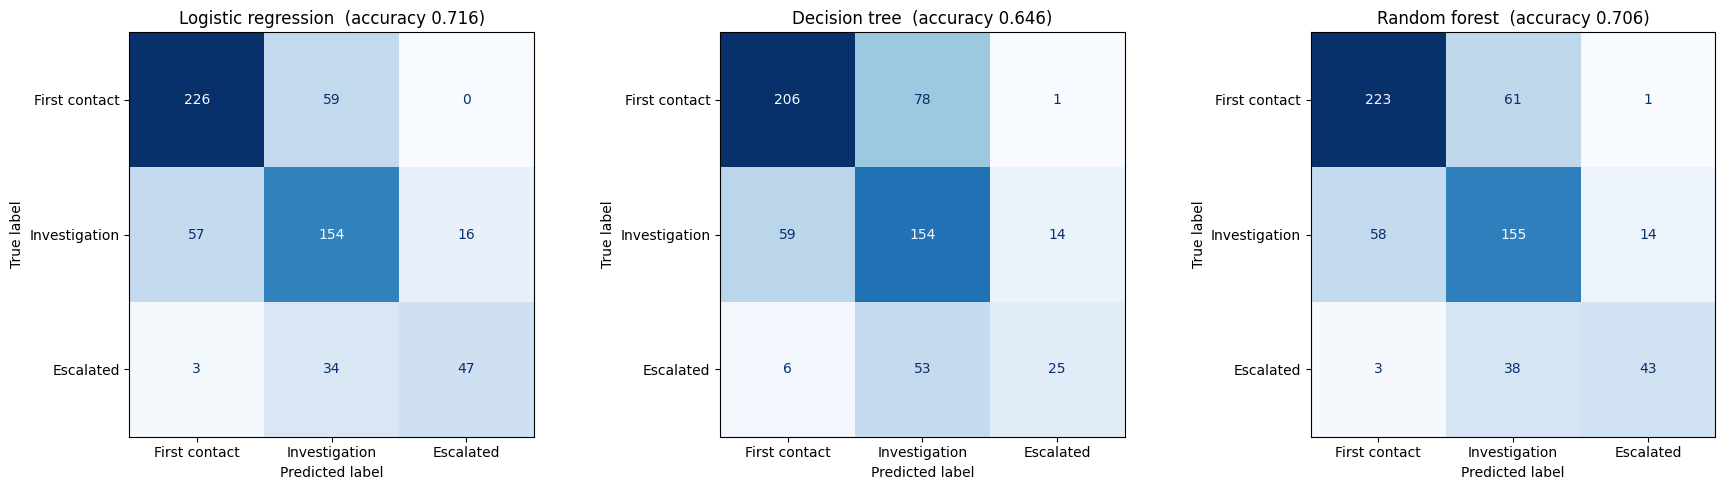

In [66]:
short_labels = ["First contact", "Investigation", "Escalated"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, labels=OUTCOME_ORDER, display_labels=short_labels,
                                          ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}  (accuracy {test_accuracy[name]:.3f})")
plt.tight_layout()
plt.show()

> **Business reading.** All three models recognise most first-contact cases and a fair share of the
> investigations. The escalations are the hard class: about half of them are predicted as "investigation",
> which is still a useful signal (they leave the fast lane), while a minority are predicted as first-contact
> resolutions and would be missed by the triage. Accuracy alone would not have told us this.
>
> Note also that the simplest model, logistic regression, is as accurate as the random forest: complexity is
> not accuracy. On tabular data with a few strong, roughly linear drivers, a linear model is hard to beat, and
> it is far easier to explain to a regulator.

### 7.4 Cross-validation

A single train/test split depends on luck: a different random split gives a slightly different accuracy.
**k-fold cross-validation** splits the training set into k parts (here 5), trains on four and tests on the
fifth, five times, and reports the five accuracies. The mean is a more reliable estimate and the spread tells
us how much the result depends on the split.

In [67]:
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name:20s} CV accuracy = {scores.mean():.3f} ± {scores.std():.3f}   folds: {np.round(scores, 3)}")

Logistic regression  CV accuracy = 0.692 ± 0.014   folds: [0.69  0.679 0.679 0.716 0.695]
Decision tree        CV accuracy = 0.639 ± 0.013   folds: [0.654 0.616 0.635 0.647 0.641]
Random forest        CV accuracy = 0.683 ± 0.019   folds: [0.665 0.665 0.679 0.716 0.689]


### 7.5 Hyper-parameter tuning with GridSearchCV

Each algorithm has settings that are not learned from the data but chosen by us: the depth of a tree, the
number of trees in a forest, the minimum number of complaints in a leaf. These are **hyper-parameters**.
`GridSearchCV` tries every combination in a grid, evaluates each with cross-validation, and keeps the best.

We tune the random forest (the model with most settings to choose) and the decision tree (the most readable
one). Tuning usually buys a few points of accuracy, rarely a miracle: the quality of the features matters more.

In [68]:
forest_grid = {"n_estimators": [100, 200], "max_depth": [6, 12, None], "min_samples_leaf": [1, 10]}
forest_search = GridSearchCV(RandomForestClassifier(random_state=42), forest_grid, cv=5, n_jobs=-1)
forest_search.fit(X_train, y_train)

print("Best parameters:", forest_search.best_params_)
print("Best cross-validated accuracy:", round(forest_search.best_score_, 3))
best_forest = forest_search.best_estimator_
print("Test accuracy of the tuned random forest:", round(best_forest.score(X_test, y_test), 3))

Best parameters: {'max_depth': 12, 'min_samples_leaf': 10, 'n_estimators': 200}
Best cross-validated accuracy: 0.689
Test accuracy of the tuned random forest: 0.693


In [69]:
# all the combinations tried, best first
search_results = pd.DataFrame(forest_search.cv_results_)[["param_n_estimators", "param_max_depth", "param_min_samples_leaf", "mean_test_score", "std_test_score"]]
search_results.sort_values("mean_test_score", ascending=False).round(3).head(8)

,param_n_estimators,param_max_depth,param_min_samples_leaf,mean_test_score,std_test_score
7,200,12,10,0.689,0.019
10,100,None,10,0.687,0.017
6,100,12,10,0.687,0.018
11,200,None,10,0.687,0.016
5,200,12,1,0.684,0.010
1,200,6,1,0.684,0.012
4,100,12,1,0.684,0.018
0,100,6,1,0.682,0.013


In [70]:
tree_grid = {"max_depth": [3, 5, 8, 12], "min_samples_leaf": [1, 10, 30]}
tree_search = GridSearchCV(DecisionTreeClassifier(random_state=42), tree_grid, cv=5)
tree_search.fit(X_train, y_train)

print("Best parameters:", tree_search.best_params_)
print("Best cross-validated accuracy:", round(tree_search.best_score_, 3))
best_tree = tree_search.best_estimator_
print("Test accuracy of the tuned decision tree:", round(best_tree.score(X_test, y_test), 3))

Best parameters: {'max_depth': 5, 'min_samples_leaf': 30}
Best cross-validated accuracy: 0.644
Test accuracy of the tuned decision tree: 0.658


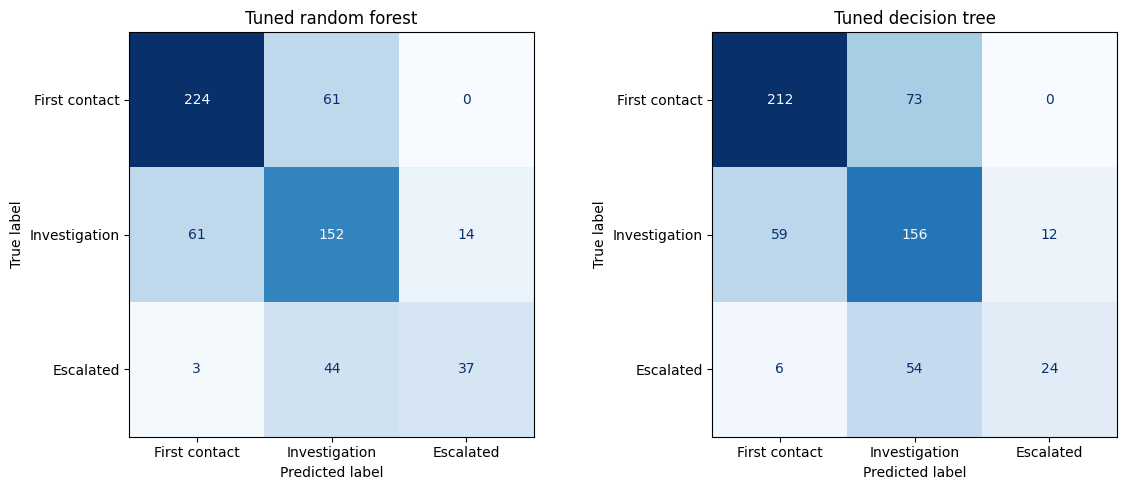

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(best_forest, X_test, y_test, labels=OUTCOME_ORDER, display_labels=short_labels, ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Tuned random forest")
ConfusionMatrixDisplay.from_estimator(best_tree, X_test, y_test, labels=OUTCOME_ORDER, display_labels=short_labels, ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Tuned decision tree")
plt.tight_layout()
plt.show()

### 7.6 What drives the prediction?

The random forest can rank the features by how much they contribute to its decisions (**feature importance**).
It confirms the EDA: the severity cluster and the channel do the work.

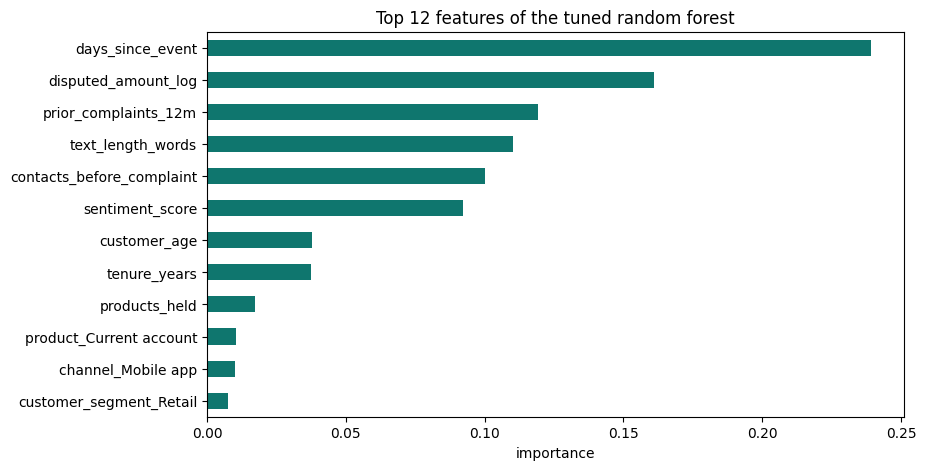

In [72]:
importance = pd.Series(best_forest.feature_importances_, index=X_train.columns).sort_values(ascending=False)
ax = importance.head(12).sort_values().plot.barh(color=TEAL, figsize=(9, 5), title="Top 12 features of the tuned random forest")
ax.set_xlabel("importance")
plt.show()

A shallow decision tree can be drawn and read as a triage rule book. Each box shows the question asked, the
number of complaints reaching it and how they split between the three outcomes. (We fit a tree of depth 3
only for readability; the tuned tree is deeper.)

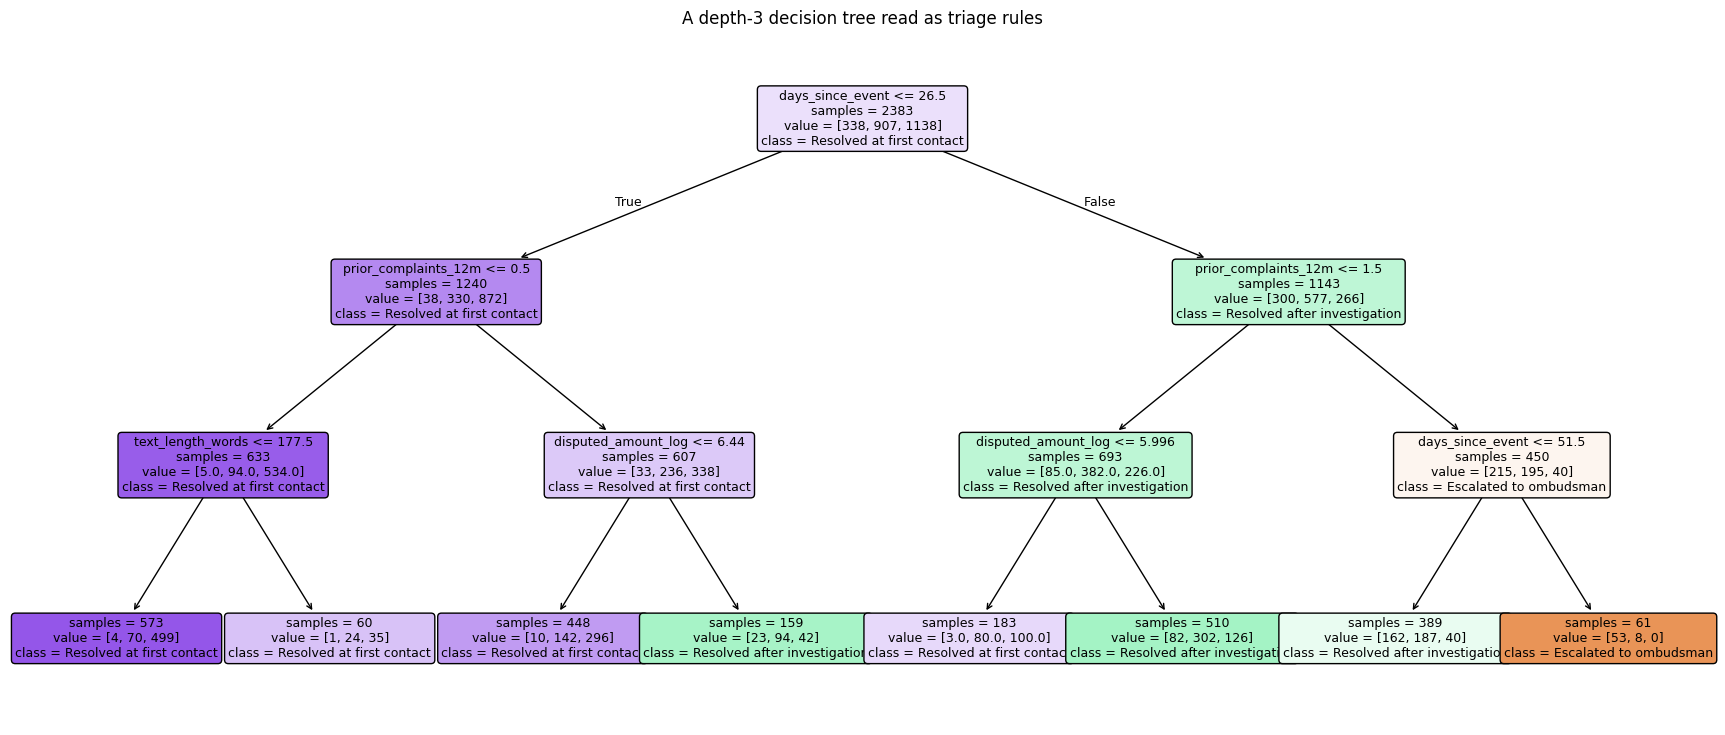

In [73]:
rule_tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

plt.figure(figsize=(22, 9))
plot_tree(rule_tree, feature_names=list(X_train.columns), class_names=list(rule_tree.classes_),
          filled=True, rounded=True, fontsize=9, impurity=False)
plt.title("A depth-3 decision tree read as triage rules")
plt.show()

> **Business insight.** The first questions of the tree are about the disputed amount, the sentiment and the
> number of contacts. These are exactly the questions a good complaints handler asks; the model has learned
> the handler's intuition from the data, and it makes it consistent across handlers and shifts.

## 8. Predictions on new complaints

Three complaints arrive this morning. We build them as a small table, apply *exactly* the same preparation
as for the training data (indicators, medians, log, one-hot encoding with the same columns) and ask the tuned
random forest for a prediction and for the probability of each outcome.

In [74]:
new_complaints = pd.DataFrame([
    {"product": "Investments", "channel": "Social media", "customer_segment": "Affluent", "customer_age": 52, "tenure_years": 11.0,
     "products_held": 4, "disputed_amount": 8500.0, "prior_complaints_12m": 2, "contacts_before_complaint": 5,
     "days_since_event": 40, "text_length_words": 310, "sentiment_score": -0.85},
    {"product": "Current account", "channel": "Mobile app", "customer_segment": "Retail", "customer_age": 29, "tenure_years": 3.0,
     "products_held": 2, "disputed_amount": 35.0, "prior_complaints_12m": 0, "contacts_before_complaint": 1,
     "days_since_event": 2, "text_length_words": 60, "sentiment_score": -0.20},
    {"product": "Mortgage", "channel": "Branch", "customer_segment": "Retail", "customer_age": 61, "tenure_years": 22.0,
     "products_held": 5, "disputed_amount": np.nan, "prior_complaints_12m": 1, "contacts_before_complaint": 3,
     "days_since_event": 55, "text_length_words": np.nan, "sentiment_score": np.nan},       # no written text, amount not recorded
])
new_complaints

,product,channel,customer_segment,customer_age,tenure_years,products_held,disputed_amount,prior_complaints_12m,contacts_before_complaint,days_since_event,text_length_words,sentiment_score
0,Investments,Social media,Affluent,52,11.0,4,8500.0,2,5,40,310.0,-0.85
1,Current account,Mobile app,Retail,29,3.0,2,35.0,0,1,2,60.0,-0.20
2,Mortgage,Branch,Retail,61,22.0,5,NaN,1,3,55,NaN,NaN


In [75]:
new = new_complaints.copy()
new["amount_missing"] = new["disputed_amount"].isna().astype(int)
new["text_available"] = new["sentiment_score"].notna().astype(int)
new = new.fillna(fill_values)                                    # the same medians used for the training data
new["disputed_amount_log"] = np.log1p(new["disputed_amount"])

X_new = pd.get_dummies(new.drop(columns="disputed_amount"), columns=categorical_cols, dtype=int)
X_new = X_new.reindex(columns=X_train.columns, fill_value=0)      # same columns, same order as in training

predictions = pd.DataFrame(best_forest.predict_proba(X_new), columns=best_forest.classes_).round(2)[OUTCOME_ORDER]
predictions.insert(0, "predicted outcome", best_forest.predict(X_new))
predictions.insert(0, "channel", new_complaints["channel"])
predictions.insert(0, "product", new_complaints["product"])
predictions

,product,channel,predicted outcome,Resolved at first contact,Resolved after investigation,Escalated to ombudsman
0,Investments,Social media,Escalated to ombudsman,0.02,0.25,0.72
1,Current account,Mobile app,Resolved at first contact,0.91,0.08,0.00
2,Mortgage,Branch,Resolved after investigation,0.20,0.49,0.31


> **From prediction to decision.** The predicted class is not the whole story: the *probability* of escalation
> is what the triage rule should use. A bank could decide, for example, that any complaint with a probability of
> escalation above 30% goes straight to a senior handler, accepting some false alarms to reduce the costly misses.
> The threshold is a business choice (cost of a miss versus cost of a false alarm), not a statistical one.

In [76]:
predictions["route to senior handler"] = predictions["Escalated to ombudsman"] >= 0.30
predictions[["product", "channel", "predicted outcome", "Escalated to ombudsman", "route to senior handler"]]

,product,channel,predicted outcome,Escalated to ombudsman,route to senior handler
0,Investments,Social media,Escalated to ombudsman,0.72,True
1,Current account,Mobile app,Resolved at first contact,0.00,False
2,Mortgage,Branch,Resolved after investigation,0.31,True


## 9. Business wrap-up

**What we learned from the data**

- The outcome is driven by a *severity cluster* (amount, negative sentiment, contacts, text length, previous
  complaints, age of the event) and by the channel and the product. Most of it is known at intake.
- Social-media and investment/mortgage complaints escalate far more often; mobile-app complaints rarely.
- February 2026 hides an operational incident that a simple volume monitor would have caught in two days.
- A blank amount is a signal, not a gap: the process that leaves it blank is the one that handles the large
  claims.
- The data had duplicates, inconsistent labels, impossible values and subtle anomalies. None of them would have
  been caught by looking at accuracy alone.

**Opportunities**

- A triage model with accuracy around 70% against a baseline below 50%, whose escalation probability can feed a
  routing rule with a business-chosen threshold.
- The same data, monitored over time, gives an early-warning system for incidents and product problems.
- The multivariate outliers give the data-quality team a short, prioritised review list.

**Risks and controls**

- **Leakage**: keep the "known at intake" discipline for every feature, and be suspicious of any accuracy that
  looks too good.
- **Drift**: the incident period shows how fast the data can change; the model needs monitoring after deployment.
- **Fairness**: check that accuracy and, above all, the missed escalations are not concentrated in one segment
  or age group. The cell below is a first check.
- **Oversight**: the prediction supports the handler; the handler decides, and the exceptions are logged.

In [77]:
# a first fairness check: accuracy of the tuned random forest by customer segment on the test set
check = data.loc[X_test.index, ["customer_segment", "channel"]].copy()
check["correct"] = (best_forest.predict(X_test) == y_test.values)
print(check.groupby("customer_segment")["correct"].agg(["mean", "count"]).round(3))

                   mean  count
customer_segment              
Affluent          0.713    115
Private           0.750     48
Retail            0.691    376
SME               0.612     49
Unknown           0.625      8


Accuracy is not identical across segments. With a few dozen SME and private-banking complaints in the test set
the differences may well be noise, but this is the table that has to exist, and be discussed, before any
deployment; a second version should look at the missed escalations rather than at overall accuracy.

**Where this connects to the rest of the course**

- The sentiment score and the text length come from an LLM reading the complaint text: the prompt-engineering
  module shows how to produce them, and how to measure their quality.
- Everything done here by hand (imputation, encoding, tuning) becomes a pipeline in the MLOps/LLMOps module.
- The fairness and oversight questions return in the governance and responsible-AI modules.